# Notebook 62: Surrogate Populations

In [1]:
nb_id = 62

In this notebook, we replace linear interpolation with the analytical CHE model developed in BN71 to generated interpolated populations from MESA grids for merger rate computation. If we consider that model, being physically motivated and validated against the high-resolution `00_fiducial` dataset, to be a reliable extrapolator, this then allows us to compute merger rates from the low-resolution MESA datasets `02_weak_winds`-`11_efficient_mix`. This allows us a much clearer view of the effect of key parameters (wind, CHE window) on the final contribution of the CHE channel to the BBH merger rate population, the conditions necessary for the production of the $35\,\mathrm{M}_\odot$ peak, and other possible contributions of the CHE channel.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

from scipy.optimize import root_scalar
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import gc

# fitting
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from pytensor.compile.ops import as_op
import xarray as xr

# mesa
import mesa_reader as mr

# custom
import sys
sys.path.append('..')
from src.util import savefig_base, DATA_DIR, MESA_DATA_DIR, NB_OUTPUT_DIR
from src.constants import Z_SUN
from src.binary import coalescence_time, p_from_a, a_from_p

/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <

In [3]:
from astropy.cosmology import WMAP9 as cosmo
t_h = cosmo.age(0).value * 1e9

In [4]:
# nb settings
plt.style.use('./plotstyle.mplstyle')
FIGURE_FOLDER = Path(f'./output/nb{nb_id}/figures')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

nb_output_dir = Path(f'./output/nb{nb_id}/data')
nb_output_dir.mkdir(parents=True, exist_ok=True)

In [5]:
# utility definitions
def savefig(fig, fname):
    """Save png, pdf and eps figure files to a nb-specific folder."""
    fname = f'nb{nb_id}_{fname}'
    plt.savefig(FIGURE_FOLDER/(fname+'.png'), bbox_inches='tight')
    plt.savefig(FIGURE_FOLDER/(fname+'.pdf'), bbox_inches='tight')
    plt.savefig(FIGURE_FOLDER/(fname+'.eps'), bbox_inches='tight')
    
@np.vectorize
def safe_log10(x):
    if np.isinf(x) or x == 0.:
        return np.nan
    else:
        return np.log10(x)

# Data

This notebook uses `core_props_df.h5` files generated with the `get_core_properties_v4.py` script. See cell below for a reference on available columns.

In [6]:
def get_core_props_df(physical_model=None):
    if physical_model is None:
        path = DATA_DIR / f'core_props_df.h5'
    else:
        path = DATA_DIR / f'{physical_model}_core_props_df.h5'
    if not path.is_file():
        print(f'File {path} not found.')
        return None
    else:
        print(f'Loading {path}...')
        core_props_df = pd.read_hdf(path)
        core_props_df['z'] = core_props_df['z_key'].astype(float)
        return core_props_df
    

In [7]:

physics_model_titles = [
    '00_fiducial',
    '01_small_fiducial',
    '02_weak_winds',
    '03_strong_winds',
    '04_flat_m_winds',
    '05_steep_m_winds',
    '06_flat_z_winds',
    '07_steep_z_winds',
    '08_late_wind_transition',
    '09_early_wind_transition',
    '10_inefficient_mix',
    '11_efficient_mix'
]

# data from previous high-res grid
core_props_df_old = get_core_props_df()

# data from new grids
core_props_df_dict = {phy_model: df for phy_model in physics_model_titles if (df := get_core_props_df(phy_model)) is not None}

Loading /mnt/home/ldesa/repos/cher/data/core_props_df.h5...


File /mnt/home/ldesa/repos/cher/data/00_fiducial_core_props_df.h5 not found.
Loading /mnt/home/ldesa/repos/cher/data/01_small_fiducial_core_props_df.h5...
File /mnt/home/ldesa/repos/cher/data/02_weak_winds_core_props_df.h5 not found.
Loading /mnt/home/ldesa/repos/cher/data/03_strong_winds_core_props_df.h5...
Loading /mnt/home/ldesa/repos/cher/data/04_flat_m_winds_core_props_df.h5...
Loading /mnt/home/ldesa/repos/cher/data/05_steep_m_winds_core_props_df.h5...
Loading /mnt/home/ldesa/repos/cher/data/06_flat_z_winds_core_props_df.h5...
Loading /mnt/home/ldesa/repos/cher/data/07_steep_z_winds_core_props_df.h5...
Loading /mnt/home/ldesa/repos/cher/data/08_late_wind_transition_core_props_df.h5...
Loading /mnt/home/ldesa/repos/cher/data/09_early_wind_transition_core_props_df.h5...
Loading /mnt/home/ldesa/repos/cher/data/10_inefficient_mix_core_props_df.h5...
Loading /mnt/home/ldesa/repos/cher/data/11_efficient_mix_core_props_df.h5...


In [8]:
def get_mi_mf_p_from_core_props_df(core_props_df, z_key):
    """Prepare mass, period and metallicity arrays as expected by fitting functions."""
    if z_key == 'all':
        subdf = core_props_df.copy()
    else:
        subdf = core_props_df[core_props_df['z_key'] == z_key].copy()
    extracted_array = subdf[['m_zams', 'm_f', 'p_spin_zams', 'z']].values
    extracted_array = extracted_array[~np.isnan(extracted_array[:, 1])].T
    MI, MF, PP, z = extracted_array
    del subdf
    gc.collect()
    return MI, MF, PP, z

# Analytical framework

Please see NB71 for details.

**Variable naming convention**: masses and mass loss rates are capitalized if they have units, and lower-case if they are dimensionless (i.e. in units of $M_r$ and $M_r/\tau_r$ respectively).

**Metallicity convention**: $Z$ is given in solar metallicities.

In [9]:
# SHARED SETTINGS
# must be shared across ALL functions, otherwise will create 
# inconsistencies
## settings for analytical model
## power laws are normallized at these reference values
Zr = 0.1 # reference metallicity, in solar metallicity
Mr = 30 # reference mass, in solar masses
tau_r = 1e6 # reference lifetime, in years

## che window settings
## the window is defined on the M_ZAMS x P_orb_ZAMS plane
## bound by two lines intercepting at (che_m_min, che_p_min)
che_m_min = 30. # Msun
che_p_min = 0.4 # d
che_lower_slope = 0.002 # d/Msun
che_upper_slope = 0.01 # d/Msun

## wind settings
## our analytical model assumes a power-law metallicity dependence
## however in MESA we see final mass become metallicity-independent
## below a certain metallicity
## we account for this manually
min_z = 0.02 # in Zsun

## other
CPU_COUNT = 96
RANDOM_SEED = 42

In [10]:
def Mf_from_Mi(Mi, Mdot_r, Z, alpha, beta, gamma, Mr=Mr, tau_r=tau_r):
    """Analytical model for final mass from wind mass loss."""
    mi = Mi/Mr
    mdot_r = Mdot_r / (Mr/tau_r)
    Z = np.maximum(Z, min_z)
    zeta = Z/Zr
    
    mf_power = mi**(1-beta) + (beta-1.) * mdot_r * zeta**gamma * mi**-alpha
    mf = mf_power**(1./(.1-beta))
    Mf = mf * Mr
    return Mf

def Af_from_Ai(Ai, Mi, Mdot_r, alpha, beta, gamma, z, Mr=Mr, tau_r=tau_r):
    """Final semi-major axis through Jeans mode mass loss."""
    mi = Mi/Mr
    mdot_r = Mdot_r / (Mr/tau_r)
    z = np.maximum(z, min_z)
    zeta = z/Zr

    root_term = 1 + (beta-1) * mdot_r * zeta**gamma * mi**(beta - (alpha+1))
    Af = Ai * root_term**(1/(beta-1))
    return Af

def delay_time(mi, mf, af, alpha, Mr=Mr, tau_r=tau_r):
    t_c = coalescence_time(mf, af, 1.)
    t_life = tau_r * (mi/Mr)**-alpha
    t_delay = t_c + t_life
    return t_delay

def get_mf_logtd(idata, mi, pi, z):
    z = np.maximum(z, min_z)
    alpha = float(idata.posterior['alpha'].median())
    beta = float(idata.posterior['beta'].median())
    gamma = float(idata.posterior['gamma'].median())
    Mdot_r = float(idata.posterior['Mdot_r'].median())
    
    mf = Mf_from_Mi(mi, Mdot_r, z, alpha, beta, gamma)
    af = Af_from_Ai(a_from_p(pi, mi, 1.), mi, Mdot_r, alpha, beta, gamma, z)
    td = delay_time(mi, mf, af, alpha)
    logtd = safe_log10(td)
    return mf, logtd



In [11]:
"""Functions for fitting alpha, beta, Mdot_r on a fixed metallicity and gamma
from pairs of metallicities."""

def fit_mf_model_single_met(core_props_df, z_key, gamma=1., verbose=False):
    """Fit alpha, beta, Mdot_r for a fixed metallicity."""
    MI, MF, PP, z = get_mi_mf_p_from_core_props_df(core_props_df, z_key)

    with pm.Model() as model:
        # priors
        alpha = pm.Normal('alpha', mu=0.2, sigma=1.0)
        beta  = pm.TruncatedNormal("beta",  mu=2.0, sigma=1.0, lower=1.0)  # widen if needed
        log_Mdot_r = pm.Normal("log_Mdot_r", mu=np.log(5e-6), sigma=1.0)
        Mdot_r = pm.Deterministic("Mdot_r", pt.exp(log_Mdot_r))
        sigma = pm.HalfNormal("sigma", sigma=max(1e-12, 0.5 * np.std(MF)))
        
        mu = Mf_from_Mi(pt.as_tensor_variable(MI), Mdot_r, z, alpha, beta, gamma)
        pm.Normal("obs", mu=mu, sigma=sigma, observed=MF)
        
        idata = pm.sample(draws=8000, tune=4000, chains=4, step=pm.DEMetropolisZ(),
                      random_seed=RANDOM_SEED, idata_kwargs={"log_likelihood": True})
    
    if verbose:
        print(az.summary(idata, var_names=["Mdot_r","alpha","beta","sigma"]))
        az.plot_pair(idata, var_names=["Mdot_r","alpha","beta"], kind="kde", marginals=True);
    
    return idata  

def gamma_root(gamma, beta, MI, MF1, zeta1, MF2, zeta2):
    """Gamma as root of this function."""
    log2 = np.log10(
        MF2**(1-beta) - MI**(1-beta)
    )
    log1 = np.log10(
        MF1**(1-beta) - MI**(1-beta)
    )
    f_beta = (log2 - log1) / np.log10(zeta2/zeta1)
    root = np.abs(gamma-f_beta)
    return root

def _logdiffexp(loga, logb):
    """Safely return log(exp(loga)-exp(logb)) assuming loga > logb."""
    if not np.all(loga > logb):
        raise ValueError('Need loga > logb for positive different within log.')
    return loga + np.log1p(-np.exp(logb - loga))

def gamma_from_pair(beta, Mi, Mf, zeta, Mi_p, Mf_p, zeta_p, tol=1e-12):
    """Compute gamma assuming usual boundaries.

    Assumes beta > 1, Mf > Mi, Mf_p > Mi_p, zeta != zeta_p.
    """
    if beta <= 1:
        return ValueError("beta must be >1.")
    if not (Mf < Mi - tol and Mf_p < Mi_p - tol):
        return ValueError("Mf must be < Mi and Mf_p must be < Mi_p.")
    if not (zeta != zeta_p):
        return ValueError("zeta must be != zeta_p.")
    
    # safe log(m^(-(beta-1)))
    t = beta - 1.0
    log_a = -t * np.log(Mf)
    log_b = -t * np.log(Mi)
    log_ap = -t * np.log(Mf_p)
    log_bp = -t * np.log(Mi_p)
    
    # safe log(mf^(-(beta-1)) - mi^(-(beta-1)))
    log_term = _logdiffexp(log_a, log_b)
    log_termp = _logdiffexp(log_ap, log_bp)
    denom = np.log(zeta_p/zeta)
    
    gamma = (log_termp - log_term) / denom
    return gamma
    
def valid_gamma_pair(row1, row2):
    """Check whether a pair of rows can be used to compute gamma."""
    if (row1.p != row2.p or row1.Mi != row2.Mi):
        return False
    elif row1.zeta == row2.zeta:
        return False
    else:
        return True

def gamma_from_beta(beta, MI, MF1, zeta1, MF2, zeta2, bracket=(1.e-6, 1.e1)):
    sol = root_scalar(
        lambda g: gamma_root(g, beta, MI, MF1, zeta1, MF2, zeta2),
        bracket=bracket
    )
    if not sol.converged:
        raise RuntimeError("Failed to converge for beta={beta}")
    return sol.root
    
def gammas_from_row_pairs(beta, data):
    """Compute gammas for all valid pairs of rows in a dataframe, with a fixed beta."""
    gammas = []
    n_rows = data.shape[0]
    for i in range(n_rows):
        row1 = data.iloc[i]
        for j in range(i+1, n_rows):
            row2 = data.iloc[j]
            if valid_gamma_pair(row1, row2):
                g = gamma_from_pair(beta, row1.Mi, row1.Mf, row1.zeta,
                                    row2.Mi, row2.Mf, row2.zeta)
                gammas.append(g)
    return np.array(gammas)

def pooled_gamma_from_b(b, df):
        GAMMA = gammas_from_row_pairs(b, df)
        return float(np.median(GAMMA))
    
def fit_mf_model_separate_gamma(core_props_df, baseline_z_key='0.1000', verbose=True):
    """Fit alpha, beta, Mdot_r for a fixed metallicity and gamma from all metallicities."""
    if baseline_z_key not in core_props_df['z_key'].unique():
        raise ValueError(f"The key '{z_key}' is not present in the 'z_key' column of core_props_df.")
    
    idata = fit_mf_model_single_met(core_props_df, baseline_z_key, gamma=0.)
    
    # build metallicity pair df for gamma estimation
    df_cols = ['zeta', 'p', 'Mi', 'Mf']
    df = pd.DataFrame(columns=df_cols)
    for z_key in core_props_df['z_key'].unique():
        MI, MF, PP, z = get_mi_mf_p_from_core_props_df(core_props_df, z_key)
        ZETA = z/Zr
        df = pd.concat([df, pd.DataFrame({'zeta': ZETA, 'p': PP, 'Mi': MI, 'Mf': MF})], ignore_index=True)
   
    
    beta_draws = idata.posterior['beta'].values.ravel()

    gamma_pooled_draws = []
    with ProcessPoolExecutor(max_workers=CPU_COUNT) as executor:
        futures = [executor.submit(pooled_gamma_from_b, b, df) for b in beta_draws]
        for future in tqdm(as_completed(futures), total=len(futures), desc='Computing gamma'):
            gamma_pooled_draws.append(future.result())

    gamma_pooled_draws = np.asarray(gamma_pooled_draws)
    
    beta_da = idata.posterior['beta']
    gamma_vals = gamma_pooled_draws.reshape(beta_da.shape)
    gamma_da = xr.DataArray(
        gamma_vals,
        dims=beta_da.dims,
        coords=beta_da.coords,
        name='gamma'
    )
    idata.posterior = idata.posterior.assign(gamma=gamma_da)
    
    if verbose:
        print(az.summary(idata, var_names=["Mdot_r","alpha","beta","gamma", "sigma"]))
        az.plot_pair(idata, var_names=["Mdot_r","alpha","beta","gamma"], kind="kde", marginals=True);
    
    return idata

In [12]:
"""Functions for fitting alpha, beta, Mdot_r and gamma simultaneously from all metallicities."""


def fit_mf_model_joint_gamma(core_props_df, verbose=True):
    """Fit alpha, beta, Mdot_r and gamma simultaneously from all metallicities."""
    MI, MF, PP, z = get_mi_mf_p_from_core_props_df(core_props_df, z_key='all')

    with pm.Model() as model:
        # priors
        alpha = pm.Normal('alpha', mu=0.2, sigma=1.0)
        beta  = pm.TruncatedNormal("beta",  mu=2.0, sigma=1.0, lower=1.0)  # widen if needed
        log_Mdot_r = pm.Normal("log_Mdot_r", mu=np.log(5e-6), sigma=1.0)
        Mdot_r = pm.Deterministic("Mdot_r", pt.exp(log_Mdot_r))
        gamma = pm.Normal("gamma", mu=0.8, sigma=0.5)
        sigma = pm.HalfNormal("sigma", sigma=max(1e-12, 0.5 * np.std(MF)))
        
        mu = Mf_from_Mi(pt.as_tensor_variable(MI), Mdot_r, z, alpha, beta, gamma)
        pm.Normal("obs", mu=mu, sigma=sigma, observed=MF)
        
        idata = pm.sample(draws=8000, tune=4000, cores=4, chains=4, step=pm.DEMetropolisZ(), random_seed=RANDOM_SEED, idata_kwargs={"log_likelihood": True}, progressbar=verbose)
    
    if verbose:
        print(az.summary(idata, var_names=['Mdot_r','alpha','beta', 'gamma', 'sigma']))
        az.plot_pair(idata, var_names=['Mdot_r','alpha','beta', 'gamma'], kind='kde', marginals=True);
    
    return idata  


# Consistency checks

We would like to confirm two things,

1. That the analytical model can reproduce MESA results from a high-resolution grid as well as the linear interpolator.
2. That the analytical model yields more reliable results than the linear interpolator when extrapolating from low-resolution grids.

We will test these hypotheses on our current highest-resolution grid, the "old" dataset.

Note that our analytical model assumes that $M_f$ depends on metallicity as $\propto Z^\gamma$ for all metallicites, while our MESA models show that $M_f$ becomes metallicity-independent below $Z\approx0.02\,Z_\odot$. We thus impose a metallicity cut on our data to avoid introducing an artificial bias.

Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]


Output()

Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 10 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
Mdot_r  0.000  0.000   0.000    0.000      0.000    0.000    2023.0    2891.0   
alpha   0.622  0.037   0.549    0.688      0.001    0.001    1821.0    2441.0   
beta    6.126  0.143   5.859    6.397      0.003    0.002    1724.0    2706.0   
gamma   3.356  0.075   3.213    3.494      0.002    0.001    1756.0    2494.0   
sigma   1.154  0.045   1.076    1.244      0.001    0.001    1561.0    2442.0   

        r_hat  
Mdot_r    1.0  
alpha     1.0  
beta      1.0  
gamma     1.0  
sigma     1.0  


67516

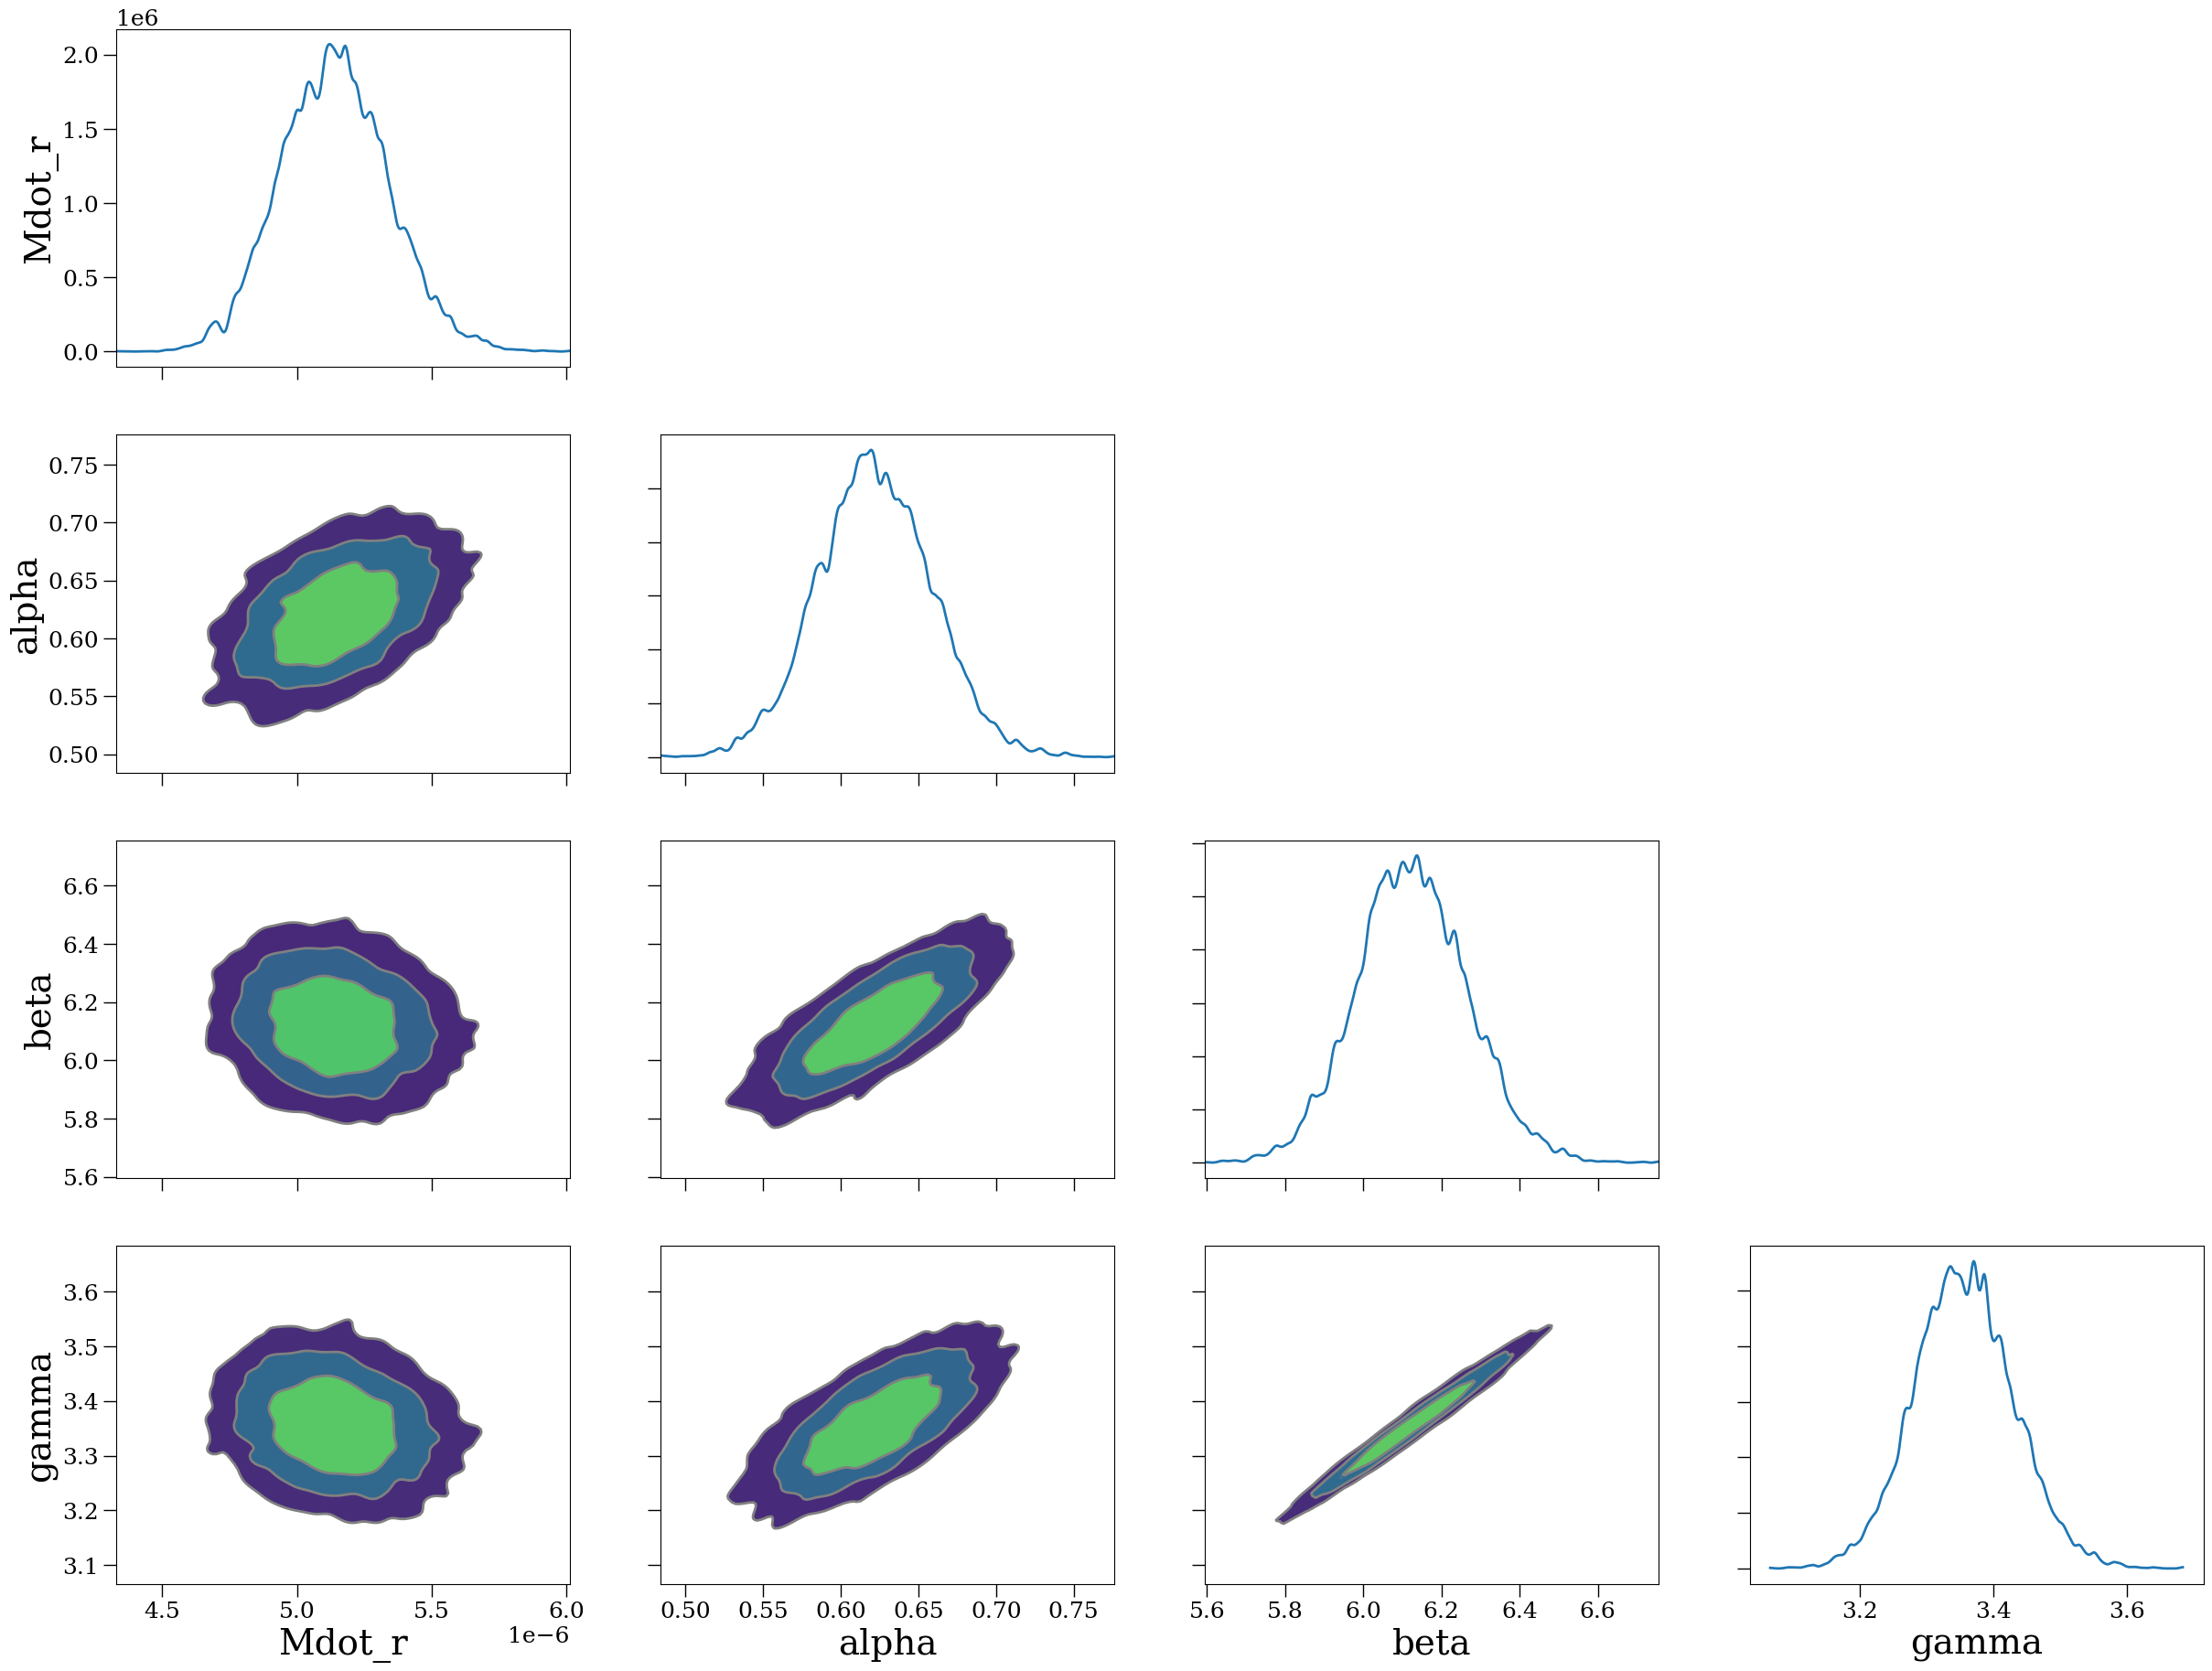

In [171]:
fit_df = core_props_df_old.copy()
fit_df = fit_df[fit_df['z'] >= min_z]
idata_old = fit_mf_model_joint_gamma(fit_df)
del fit_df
gc.collect()

In [15]:
default_multiplier_dict = {
    'mdot_r_add' : 0.,
    'mdot_r_mult' : 1.,
    'alpha_add' : 0.,
    'alpha_mult' : 1.,
    'beta_add' : 0.,
    'beta_mult' : 1.,
    'gamma_add' : 0.,
    'gamma_mult' : 1.
}

def plot_fixed_z(ax, idata, core_props_df, z_key, multiplier_dict=default_multiplier_dict, legend=False, 
                 label_axes=False):
    X, Y, P, z = get_mi_mf_p_from_core_props_df(core_props_df, z_key)
    z = z[0]

    # 1) Build a smooth grid in Mi
    xg = np.linspace(X.min(), X.max(), 300)
    
    # 2) Pull posterior draws for parameters
    post = idata.posterior
    
    sigma_samps  = post["sigma"].stack(sample=("chain","draw")).values
    
    Mdot_r_samps = post["Mdot_r"].stack(sample=("chain","draw")).values
    Mdot_r_samps = Mdot_r_samps * multiplier_dict['mdot_r_mult'] + multiplier_dict['mdot_r_add']
    
    alpha_samps = post["alpha"].stack(sample=("chain","draw")).values
    alpha_samps = alpha_samps * multiplier_dict['alpha_mult'] + multiplier_dict['alpha_add']
    
    beta_samps = post["beta"].stack(sample=("chain","draw")).values
    beta_samps = beta_samps * multiplier_dict['beta_mult'] + multiplier_dict['beta_add']

    gamma_samps  = post["gamma"].stack(sample=("chain","draw")).values
    gamma_samps = gamma_samps * multiplier_dict['gamma_mult'] + multiplier_dict['gamma_add']

    # Optionally thin to speed up the predictive grid
    thin = min(2000, Mdot_r_samps.size)
    idx  = np.random.default_rng(0).choice(Mdot_r_samps.size, size=thin, replace=False)

    Mdot_r_samps = Mdot_r_samps[idx]
    alpha_samps  = alpha_samps[idx]
    beta_samps   = beta_samps[idx]
    sigma_samps  = sigma_samps[idx]
    gamma_samps = gamma_samps[idx]

    # 3) Evaluate the model on the grid for each draw
    #    (parameter-uncertainty only; comment IN the noise line below to include observation mismatch)
    Yg = np.empty((thin, xg.size))
    for i, (mr, a, b, g) in enumerate(zip(Mdot_r_samps, alpha_samps, beta_samps, gamma_samps)):
        y_mean = Mf_from_Mi(xg, mr, z, a, b, g)
        # y = y_mean + np.random.normal(0, sigma_samps[i], size=xg.size)  # include noise if desired
        Yg[i] = y_mean

    # 4) Summaries for shaded bands
    q05, q16, q50, q84, q95 = np.percentile(Yg, [2.5, 16, 50, 84, 97.5], axis=0)

    # 5) Plot
    ax.plot(X, Y, 'b.', markersize=10, label='simulation results')

    ax.fill_between(xg, q05, q95, alpha=0.15, label='95% credible band')
    ax.fill_between(xg, q16, q84, alpha=0.25, label='68% credible band')
    ax.plot(xg, q50, 'r-', lw=2, label='posterior median fit')
    
    if label_axes:
        ax.set_xlabel(r'$M_i/\mathrm{M}_\odot$')
        ax.set_ylabel(r'$M_f/\mathrm{M}_\odot$')
    if legend:
        ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1,1))
    ax.set_title(f'$Z/\\mathrm{{Z}}_\\odot = {z:.2g}$')


Text(0.5, 0, '$M_i/\\mathrm{M}_\\odot$')

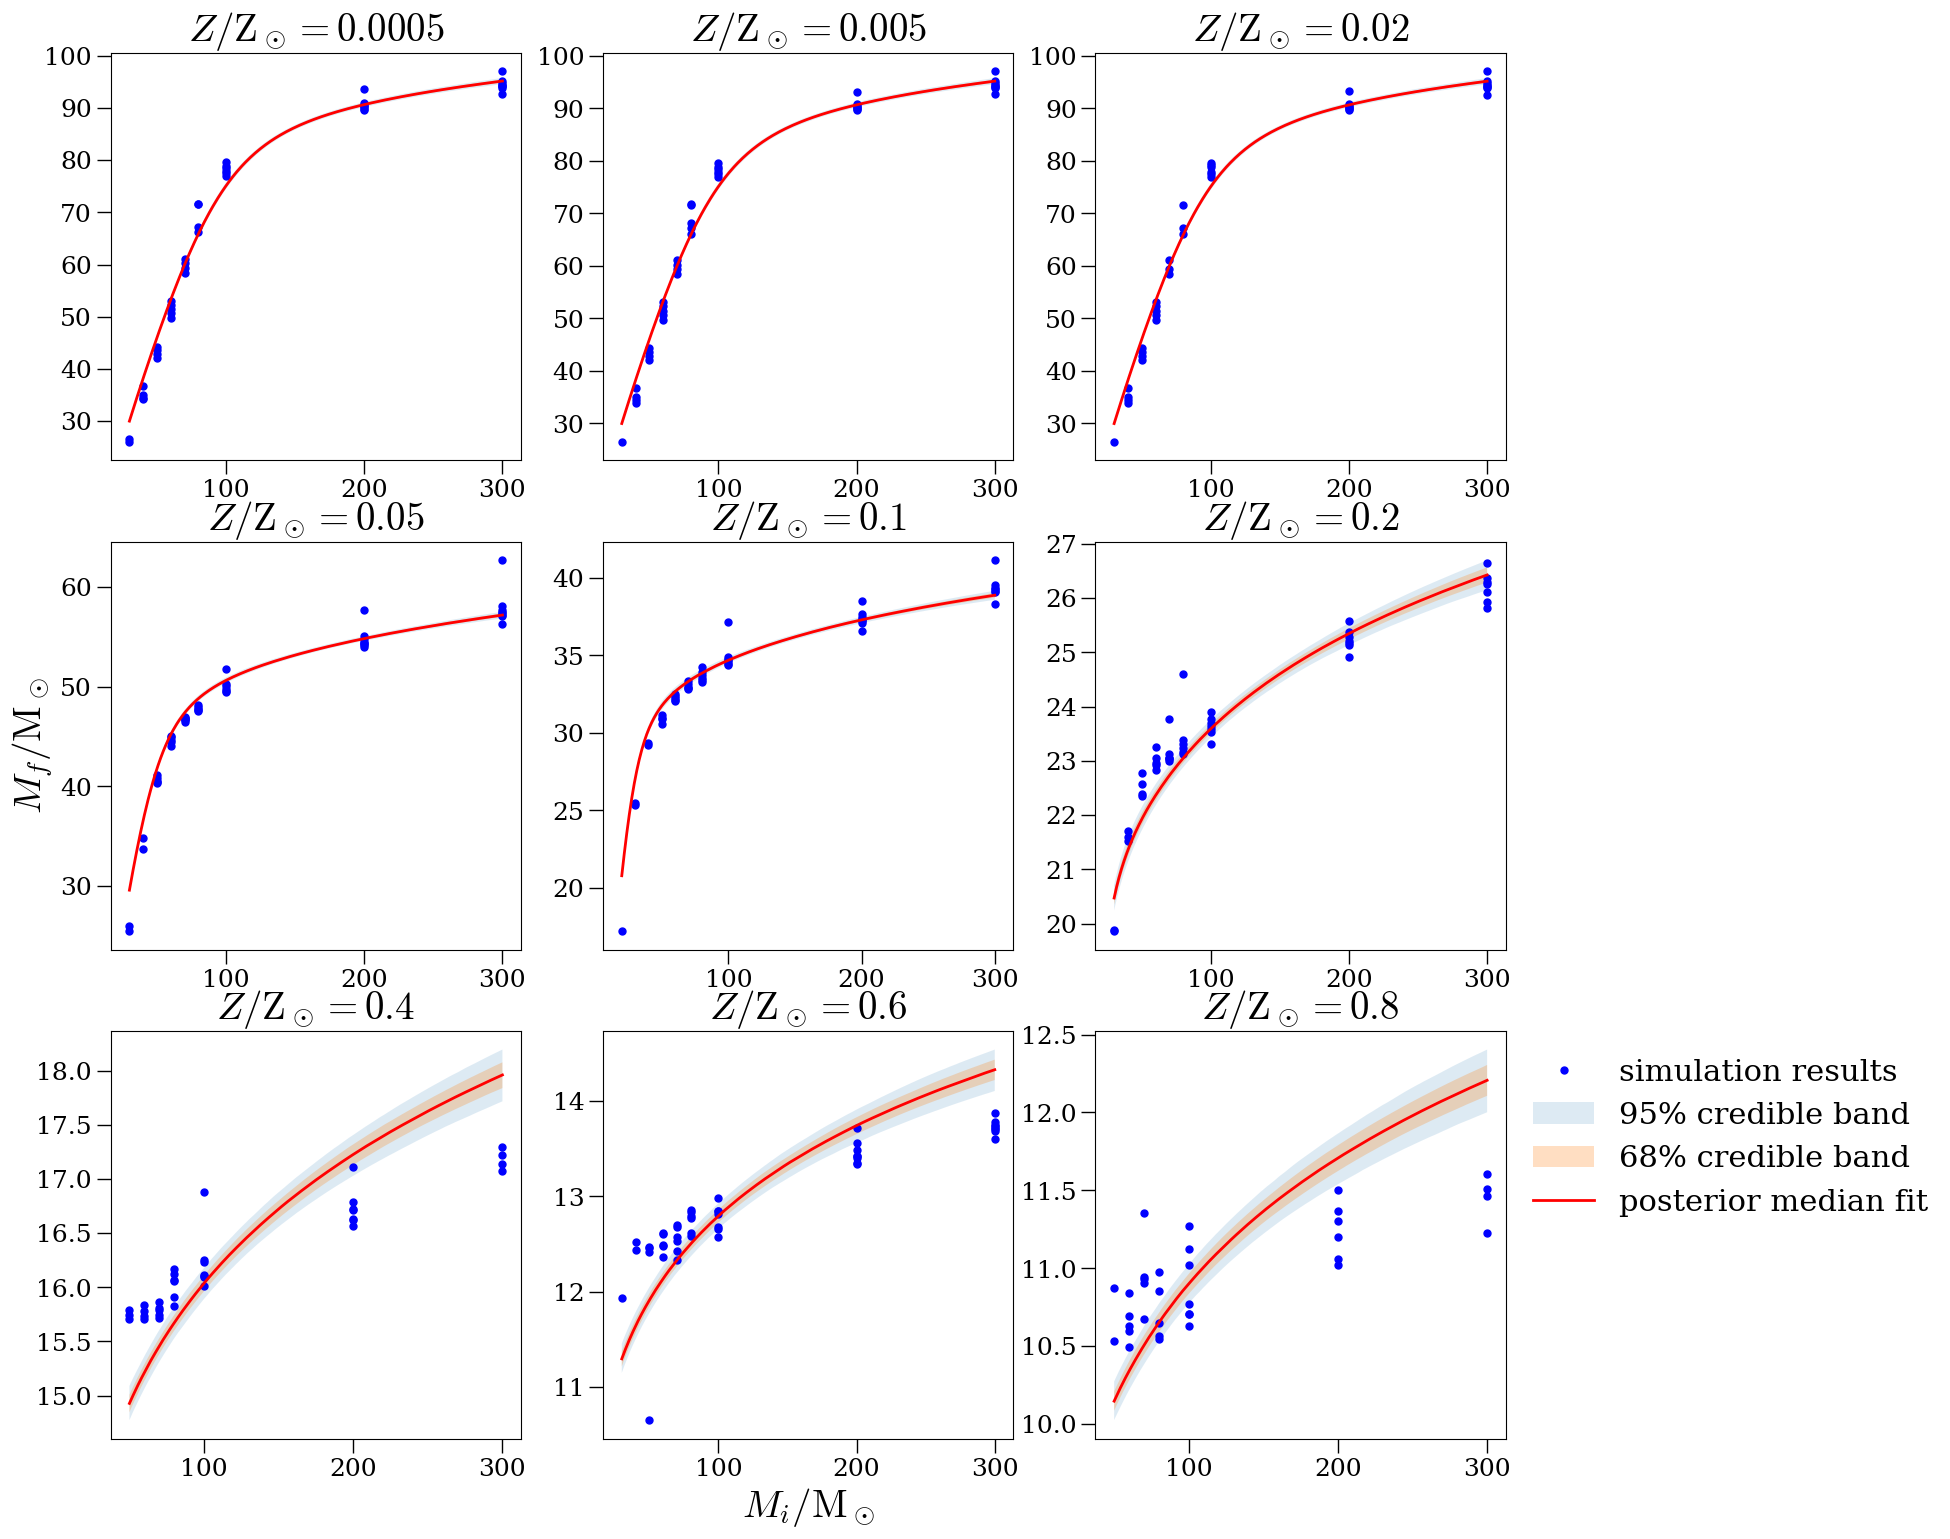

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

z_keys = core_props_df_old['z_key'].unique()
z_keys = z_keys[np.argsort(z_keys.astype(float))]
for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes.ravel())):
    legend = False if i < len(axes.ravel())-1 else True
    plot_fixed_z(ax, idata_old, core_props_df_old, zdivzsun_key, legend=legend, label_axes=False)
axes[1,0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[2,1].set_xlabel('$M_i/\\mathrm{M}_\\odot$')

In [214]:
# ---------- helpers: draw parameters from idata.posterior ----------
def _draw_params(idata, multiplier_dict, thin=2000, rng=RANDOM_SEED):
    post = idata.posterior
    rng = np.random.default_rng(rng)

    # stack chains/draws -> 1D samples per param
    sig  = post["sigma"].stack(sample=("chain","draw")).values
    mr   = post["Mdot_r"].stack(sample=("chain","draw")).values
    a    = post["alpha"].stack(sample=("chain","draw")).values
    b    = post["beta"].stack(sample=("chain","draw")).values
    g    = post["gamma"].stack(sample=("chain","draw")).values

    # apply multipliers (match your plotting function)
    mr = mr * multiplier_dict.get('mdot_r_mult', 1.) + multiplier_dict.get('mdot_r_add', 0.)
    a  = a  * multiplier_dict.get('alpha_mult', 1.)  + multiplier_dict.get('alpha_add', 0.)
    b  = b  * multiplier_dict.get('beta_mult', 1.)   + multiplier_dict.get('beta_add', 0.)
    g  = g  * multiplier_dict.get('gamma_mult', 1.)  + multiplier_dict.get('gamma_add', 0.)

    n = min(thin, mr.size)
    idx = rng.choice(mr.size, size=n, replace=False)
    return mr[idx], a[idx], b[idx], g[idx], sig[idx]

# ---------- posterior predictive draws at given Mi (fixed z) ----------
def posterior_predictive_draws_at_Mi(idata, Mi, z, multiplier_dict=default_multiplier_dict,
                                     thin=2000, include_noise=True, rng=RANDOM_SEED):
    """
    Returns Ydraws of shape (n_draws, n_points) for the given Mi points at fixed z.
    include_noise=True adds Normal(0, sigma) to each draw.
    """
    Mi = np.asarray(Mi, dtype=float)
    mask = np.isfinite(Mi)
    if not mask.any():
        return np.empty((0,0)), mask

    mr, a, b, g, sig = _draw_params(idata, multiplier_dict, thin=thin, rng=rng)
    n_draws = mr.size
    Y = np.empty((n_draws, mask.sum()), dtype=float)

    for i, (mri, ai, bi, gi) in enumerate(zip(mr, a, b, g)):
        mu = Mf_from_Mi(Mi[mask], mri, z, ai, bi, gi)
        if include_noise:
            Y[i] = mu + np.random.default_rng(rng + i).normal(0.0, sig[i], size=mu.size)
        else:
            Y[i] = mu
    return Y, mask

# ---------- coverage and PIT ----------
def predictive_coverage(y_true, Ydraws, alphas=(0.32, 0.05)):
    """
    y_true: shape (n_points,)
    Ydraws: shape (n_draws, n_points) predictive draws
    Returns coverage dict for 68% (alpha=0.32) and 95% (alpha=0.05), plus per-point flags.
    """
    y_true = np.asarray(y_true, dtype=float)
    finite = np.isfinite(y_true) & np.all(np.isfinite(Ydraws), axis=0)
    if not finite.any():
        return {"n": 0, "cov68": np.nan, "cov95": np.nan, "inside68": [], "inside95": []}

    q16 = np.percentile(Ydraws[:, finite], 16, axis=0)
    q84 = np.percentile(Ydraws[:, finite], 84, axis=0)
    q025 = np.percentile(Ydraws[:, finite], 2.5, axis=0)
    q975 = np.percentile(Ydraws[:, finite], 97.5, axis=0)

    yt = y_true[finite]
    inside68 = (yt >= q16) & (yt <= q84)
    inside95 = (yt >= q025) & (yt <= q975)

    return {
        "n": int(finite.sum()),
        "cov68": float(inside68.mean()),
        "cov95": float(inside95.mean()),
        "inside68": inside68,
        "inside95": inside95,
        "finite_mask": finite
    }

def predictive_pit(y_true, Ydraws):
    """
    PIT values: for each point, fraction of draws <= y_true.
    Returns array of size n_points (NaN where y_true not finite or no draws).
    """
    y_true = np.asarray(y_true, dtype=float)
    n = y_true.size
    pit = np.full(n, np.nan, dtype=float)
    finite = np.isfinite(y_true) & np.all(np.isfinite(Ydraws), axis=0)
    if finite.any():
        ranks = (Ydraws[:, finite] <= y_true[finite]).mean(axis=0)
        pit[finite] = ranks
    return pit

# ---------- PPC plot at observed Mi for a fixed z ----------
def ppc_fixed_z(ax, idata, core_props_df, z_key, multiplier_dict=default_multiplier_dict,
                thin=2000, include_noise=True, label_axes=False, legend=False, rng=RANDOM_SEED):
    """
    For the given z slice, draw posterior predictive at the *observed* Mi points,
    shade 68/95% bands at those x's, overlay observations, and print coverage.
    """
    X, Y, P, z_arr = get_mi_mf_p_from_core_props_df(core_props_df, z_key)
    z = float(np.asarray(z_arr)[0])
    finite = np.isfinite(X) & np.isfinite(Y)
    Xo, Yo = X[finite], Y[finite]

    Ydraws, xmask = posterior_predictive_draws_at_Mi(idata, Xo, z, multiplier_dict,
                                                     thin=thin, include_noise=include_noise, rng=rng)
    # quantiles at observed x's
    q025, q16, q50, q84, q975 = np.percentile(Ydraws, [2.5, 16, 50, 84, 97.5], axis=0)

    # plot observations
    ax.plot(Xo, Yo, '.', ms=9, alpha=0.9, label='data')

    # connect by x-order to make bands less jagged
    order = np.argsort(Xo)
    ax.fill_between(Xo[order], q025[order], q975[order], alpha=0.15, label='95% pred. band')
    ax.fill_between(Xo[order], q16[order],  q84[order],  alpha=0.25, label='68% pred. band')
    ax.plot(Xo[order], q50[order], 'r-', lw=2, label='pred. median')

    # coverage
    cov = predictive_coverage(Yo, Ydraws)
    print(f"[PPC z={z:.3g}] n={cov['n']}, coverage68={cov['cov68']:.2%}, coverage95={cov['cov95']:.2%}")

    if label_axes:
        ax.set_xlabel(r'$M_i/\mathrm{M}_\odot$')
        ax.set_ylabel(r'$M_f/\mathrm{M}_\odot$')
    ax.set_title(f'PPC at observed $M_i$ (Z/Z$_\\odot$={z:.2g})')
    if legend:
        ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1,1))

    return {"cov": cov, "Ydraws": Ydraws, "X": Xo, "Y": Yo, "z": z}

# ---------- residuals for a fixed z ----------
def residuals_fixed_z(idata, core_props_df, z_key, multiplier_dict=default_multiplier_dict):
    """
    Residuals r = Y - mu(X) using posterior *median* parameters (no added noise).
    Returns dict with X, Y, mu, r, and z.
    """
    X, Y, P, z_arr = get_mi_mf_p_from_core_props_df(core_props_df, z_key)
    z = float(np.asarray(z_arr)[0])

    post = idata.posterior
    # median parameters
    mr   = np.median(post["Mdot_r"].values)
    a    = np.median(post["alpha"].values)
    b    = np.median(post["beta"].values)
    g    = np.median(post["gamma"].values)

    # apply multipliers
    mr = mr * multiplier_dict.get('mdot_r_mult', 1.) + multiplier_dict.get('mdot_r_add', 0.)
    a  = a  * multiplier_dict.get('alpha_mult', 1.)  + multiplier_dict.get('alpha_add', 0.)
    b  = b  * multiplier_dict.get('beta_mult', 1.)   + multiplier_dict.get('beta_add', 0.)
    g  = g  * multiplier_dict.get('gamma_mult', 1.)  + multiplier_dict.get('gamma_add', 0.)

    finite = np.isfinite(X) & np.isfinite(Y)
    Xo, Yo = X[finite], Y[finite]
    mu = Mf_from_Mi(Xo, mr, z, a, b, g)
    r  = Yo - mu
    return {"X": Xo, "Y": Yo, "mu": mu, "resid": r, "z": z}

# ---------- residual plots (3-panel) ----------
def plot_residuals_fixed_z(axs, idata, core_props_df, z_key, multiplier_dict=default_multiplier_dict,
                           label_axes=False):
    """
    axs: iterable of 3 Matplotlib axes.
    Panel A: residual vs Mi
    Panel B: residual vs fitted (mu)
    Panel C: histogram of residuals + 0 line
    """
    out = residuals_fixed_z(idata, core_props_df, z_key, multiplier_dict)
    X, mu, r, z = out["X"], out["mu"], out["resid"], out["z"]

    # A: r vs Mi
    ax = axs[0]
    ax.axhline(0, lw=1, alpha=0.6)
    ax.plot(X, r, '.', alpha=0.9)
    ax.set_title(f"Residuals vs $M_i$ (Z/Z$_\\odot$={z:.2g})")
    if label_axes:
        ax.set_xlabel(r'$M_i/\mathrm{M}_\odot$')
        ax.set_ylabel('Residual $M_f - \\hat M_f$')

    # B: r vs fitted
    ax = axs[1]
    ax.axhline(0, lw=1, alpha=0.6)
    ax.plot(mu, r, '.', alpha=0.9)
    ax.set_title("Residuals vs fitted")
    if label_axes:
        ax.set_xlabel(r'$\hat M_f$')
        ax.set_ylabel('Residual')

    # C: histogram of residuals
    ax = axs[2]
    ax.hist(r[np.isfinite(r)], bins=20, density=True, alpha=0.8)
    ax.axvline(0, lw=1)
    ax.set_title("Residuals histogram")
    if label_axes:
        ax.set_xlabel('Residual')
        ax.set_ylabel('Density')

    return out

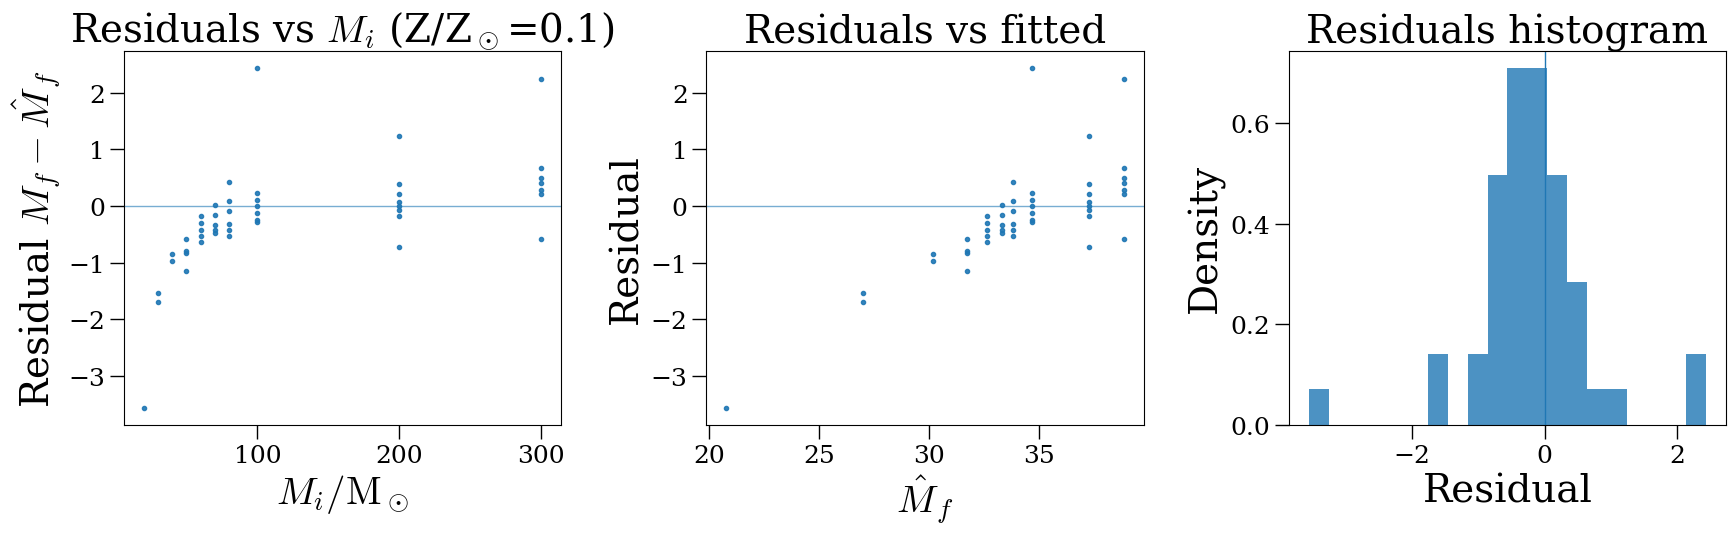

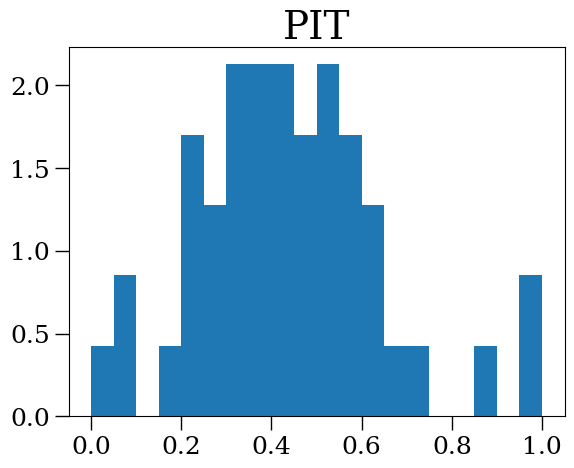

In [216]:
# ---------- example usage ----------
fig, axs = plt.subplots(1, 3, figsize=(18,6))
res_info = plot_residuals_fixed_z(axs, idata_old, core_props_df_old, z_key='0.1',
                                   multiplier_dict=default_multiplier_dict, label_axes=True)
plt.tight_layout(); plt.show()

# If you want a global PIT diagnostic for a z-slice:
pit = predictive_pit(ppc_info["Y"], ppc_info["Ydraws"])
plt.figure(); plt.hist(pit[np.isfinite(pit)], bins=20, range=(0,1), density=True); plt.title("PIT"); plt.show()

# Building a new "interpolator"

In [13]:
from scipy.interpolate import interp1d
from functools import partial

In [14]:
class PMZLinearInterpolator:
    
    def __init__(self, data, var='m_f', bounds_error=False, fill_value=np.nan, verbose=False):
        self.data = data
        self.var = var
        self.bounds_error = bounds_error
        self.fill_value = fill_value
        self.verbose = verbose 
        self.p_interpolators = self._get_p_interpolators()       
        
    def _get_p_interpolators(self):
        """Sets p interpolators for all m_zams and z_key combinations."""
        p_interpolators = {}
        for z_key in self.data.z_key.unique():
            p_interpolators[z_key] = {}
            for m_key in self.data.m_zams.unique():
                p_interpolator = self._get_p_interpolator(m_key, z_key)
                p_interpolators[z_key][m_key] = p_interpolator
        return p_interpolators

    def _get_p_interpolator(self, m_key, z_key):
        ip_data = self.data.copy()
        ip_data = ip_data[ip_data.is_che & ~ip_data.is_merger_at_zams]
        
        m_zams = round(float(m_key), 1)
        ip_x = ip_data[
            (ip_data.z_key == z_key)
            & (ip_data.m_zams == m_zams)
        ].p_spin_zams.values
        ip_y = ip_data[
            (ip_data.z_key == z_key)
            & (ip_data.m_zams == m_zams)
        ][self.var].values
        
        if len(ip_x) == 0 or len(ip_y) == 0:
            if self.bounds_error:
                raise ValueError(f'No data for m_zams={m_zams}, z={z_key}')
            else:
                if self.verbose:
                    print(f'Warning: No data for m_zams={m_zams}, z_key={z_key}. Returning empty interpolator.')
                return interp1d([np.nan], [np.nan], bounds_error=False, fill_value=self.fill_value)
        
        ip_y = ip_y[ip_x.argsort()]
        ip_x = np.sort(ip_x)
        series = pd.Series(ip_y, index=ip_x)
        ip_y = series.interpolate(method='slinear', limit_area=None, limit_direction='both').values

        p_interpolator = interp1d(
            ip_x,
            ip_y,
            bounds_error=self.bounds_error,
            fill_value=self.fill_value
        )
        return p_interpolator

    def _get_m_interpolator(self, p_spin_zams, z_key):
        ip_x = []
        ip_y = []
        for m_key, p_interpolator in self.p_interpolators[z_key].items():
            ip_x.append(float(m_key))
            ip_y.append(p_interpolator(p_spin_zams))
        ip_x = np.array(ip_x)
        ip_y = np.array(ip_y)

        ip_y = ip_y[ip_x.argsort()]
        ip_x = np.sort(ip_x)    
        #series = pd.Series(ip_y, index=ip_x)
        #ip_y = series.interpolate(method='linear', limit_area='inside', limit_direction='both').values
                # Find indices where ip_y is nan and surrounded by non-nans

        m_interpolator = interp1d(
            ip_x, 
            ip_y, 
            bounds_error=self.bounds_error, 
            fill_value=self.fill_value
        )
        return m_interpolator
    
    def _get_z_interpolator(self, m_zams, p_spin_zams):
        ip_x = []
        ip_y = []
        for z_key in self.p_interpolators.keys():
            m_interpolator = self._get_m_interpolator(p_spin_zams, z_key)
            ip_x.append(np.log10(float(z_key)))
            ip_y.append(m_interpolator(m_zams))
        ip_x = np.array(ip_x)
        ip_y = np.array(ip_y)
            
        ip_y = ip_y[ip_x.argsort()]
        ip_x = np.sort(ip_x)
        #series = pd.Series(ip_y, index=ip_x)
        #ip_y = series.interpolate(method='linear', limit_area='inside', limit_direction='both').values
            
        logz_interpolator = interp1d(
            ip_x, 
            ip_y, 
            bounds_error=self.bounds_error, 
            fill_value=self.fill_value
        )
        def z_interpolator(z):
            return logz_interpolator(np.log10(z))
        
        return z_interpolator
    
    def get_var(self, m, p, z):
        interpolator = self._get_z_interpolator(m, p)
        return interpolator(z)
            

In [15]:
"""Metallicity distributions."""

from scipy.stats import norm as NormDist
from scipy.interpolate import CubicSpline

def find_metallicity_distribution(redshifts, min_logZ_COMPAS, max_logZ_COMPAS,
                                  mu0=0.035, muz=-0.23, sigma_0=0.39, 
                                  sigma_z=0.0, alpha=0.0, min_logZ=-12.0, 
                                  max_logZ=0.0, step_logZ=0.01):
    """
    Calculate the distribution of metallicities at different redshifts 
    using a log skew normal distribution. The log-normal distribution 
    is a special case of this log skew normal distribution and is 
    retrieved by setting the skewness to zero (alpha=0). Based on the 
    method in Neijssel+19. Default values retrieve the dP/dZ 
    distribution used in Neijssel+19. See van Son+2022 for skewed 
    log-normal distribution.

    NOTE: This assumes that metallicities in COMPAS are drawn from a 
    flat-in-log distribution!

    Args:
        max_redshift       --> [float] Max redshift for calculation
        redshift_step      --> [float] Step used in redshift calculation
        min_logZ_COMPAS    --> [float] Min logZ value that COMPAS samples
        max_logZ_COMPAS    --> [float] Max logZ value that COMPAS samples
        mu0                --> [float] Location (mean in normal) at z=0
        muz                --> [float] Redshift scaling of location
        sigma_0            --> [float] Scale (variance in normal) at z=0
        sigma_z            --> [float] Redshift scaling of the scale
        alpha              --> [float] Shape (skewness, alpha=0 gives 
                                  normal dist as in Neijssel+19)
        min_logZ           --> [float] Min logZ for dPdlogZ calculation
        max_logZ           --> [float] Max logZ for dPdlogZ calculation
        step_logZ          --> [float] Step size for logZ range

    Returns:
        dPdlogZ            --> [2D float array] Probability of getting a 
                                  particular logZ at a certain redshift
        metallicities      --> [list of floats] Metallicities at which 
                                  dPdlogZ is evaluated
        p_draw_metallicity --> [float] Probability of drawing a certain 
                                  metallicity in COMPAS
    """
    # Log-linear redshift dependence of sigma
    sigma = sigma_0 * 10**(sigma_z * redshifts)

    # Mean metallicities evolve with redshift (Langer & Norman 2006)
    mean_metallicities = mu0 * 10**(muz * redshifts)

    # Rewrite expected value of log-skew-normal to retrieve mu
    beta = alpha / (np.sqrt(1 + alpha**2))
    PHI = NormDist.cdf(beta * sigma)
    mu_metallicities = np.log(mean_metallicities / 2. / 
                              (np.exp(0.5 * sigma**2) * PHI))

    # Create a range of metallicities (x-values or random variables)
    log_metallicities = np.arange(min_logZ, max_logZ + step_logZ, step_logZ)
    metallicities = np.exp(log_metallicities)

    # Probabilities of log-skew-normal (without 1/Z factor)
    dPdlogZ = (2. / sigma[:, np.newaxis] * 
               NormDist.pdf((log_metallicities - mu_metallicities[:, np.newaxis]) / sigma[:, np.newaxis]) * 
               NormDist.cdf(alpha * (log_metallicities - mu_metallicities[:, np.newaxis]) / sigma[:, np.newaxis]))

    # Normalize distribution over all metallicities
    norm = dPdlogZ.sum(axis=-1) * step_logZ
    dPdlogZ = dPdlogZ / norm[:, np.newaxis]

    # Flat-in-log distribution for sampled metallicity in COMPAS
    p_draw_metallicity = 1 / (max_logZ_COMPAS - min_logZ_COMPAS)

    return dPdlogZ, metallicities, p_draw_metallicity

def get_metallicity_distribution_ip(redshift):
    mu0 = 0.025
    muz = -0.049
    sigma0 = 1.122
    sigmaz = 0.049
    alpha = -1.778
    min_logZ = -12.0
    max_logZ = 0.0
    step_logZ = 0.01
    min_Z = 0.0005 * Z_SUN
    max_Z = Z_SUN
    dPdlogZ, metallicities, p_draw_metallicity = find_metallicity_distribution(
        redshifts=np.asarray([redshift]),
        min_logZ_COMPAS=np.log(min_Z),
        max_logZ_COMPAS=np.log(max_Z),
        mu0=mu0,
        muz=muz,
        sigma_0=sigma0,
        sigma_z=sigmaz,
        alpha=alpha,
        min_logZ=min_logZ,
        max_logZ=max_logZ,
        step_logZ=step_logZ
        )
    spline = CubicSpline(np.log10(metallicities/Z_SUN), dPdlogZ[0])
    return spline

In [16]:
class FinalVarModel:
    
    def __init__(self, data, title='new', n_processes=CPU_COUNT, verbose=True):
        self.data = data
        self.idata = fit_mf_model_joint_gamma(data, verbose=verbose)
        self.n_processes = n_processes
        self.title = title

    @staticmethod
    @np.vectorize
    def get_che_mask(m, p, che_m_min=che_m_min, che_p_min=che_p_min, che_lower_slope=che_lower_slope, che_upper_slope=che_upper_slope):
        """Check whether a (m, p) pair is in the CHE window."""
        p_lower = che_lower_slope * (m - che_m_min) + che_p_min
        p_upper = che_upper_slope * (m - che_m_min) + che_p_min
        if m >= che_m_min and p_lower <= p <= p_upper:
            return True
        else:
            return False
        
    def predict(self, job, var, model='interpolator', che_mask=True):
        """Pickable function to interpolate from a pop array.

        Job is a (n_pop, n_var) array where n_var > 3. job[:,0] contains
        metallicities, job[:,1] contains m_zams and job[:,2] contains
        p_spin_zams.
        """
        if che_mask:
            che_mask = self.get_che_mask(job[:, 1], job[:, 2])
        else:
            che_mask = np.ones_like(che_mask, dtype=bool)
        if var == 'm_f' and model == 'surrogate':
            result = np.where(
                che_mask,
                get_mf_logtd(self.idata, job[:, 1], job[:, 2], job[:, 0])[0],
                np.nan
            )
        elif var == 'log_t_d' and model == 'surrogate':
            result = np.where(
                che_mask,
                get_mf_logtd(self.idata, job[:, 1], job[:, 2], job[:, 0])[1],
                np.nan
            )
        elif model == 'interpolator':
            interpolator = PMZLinearInterpolator(self.data, var=var)
            vec_f = np.vectorize(interpolator.get_var)
            result = np.where(
                che_mask,
                vec_f(job[:, 1], job[:, 2], job[:, 0]),
                np.nan
            )
        else:
            raise ValueError(f'Unknown model {model}. Options are "interpolator" and "surrogate".')
        return result

    def parallel_set_sample_var(self, sample, var, var_col_i, model='interpolator', che_mask=True):
        print(f'Model: {model}, che_mask: {che_mask}')
        run_job = partial(self.predict, var=var, model=model, che_mask=che_mask)

        # Get the indices for each split
        split_indices = np.array_split(np.arange(len(sample)), self.n_processes)
        jobs = [sample[idx] for idx in split_indices]
        
        with ProcessPoolExecutor(max_workers=self.n_processes) as executor:
            futures = {
                executor.submit(run_job, job): job_index for job_index, job in enumerate(jobs)
            }
            
            for future in tqdm(as_completed(futures), total=len(futures), desc=f'Collecting {var}'):
                job_index = futures[future]
                try:
                    result = future.result()
                except Exception as e:
                    print(f'Error in job {job_index}: {e}')
                    continue
                # Assign using the correct indices
                sample[split_indices[job_index], var_col_i] = result
        return sample
    
    def save_sample_msample(self, sample, min_zdivzsun, max_zdivzsun, res):
        msample = sample[sample[:, -1] <= np.log10(t_h)].copy()
        np.save(DATA_DIR/f'{self.title}_ip_pop_minz{min_zdivzsun}_maxz{max_zdivzsun}_res{res:.0e}_enhanced_w.npy', sample)
        print(f'Saved sample with {len(sample)} stars to {DATA_DIR/f"{self.title}_ip_pop_minz{min_zdivzsun}_maxz{max_zdivzsun}_res{res:.0e}_enhanced_w.npy"}')
        np.save(DATA_DIR/f'{self.title}_ip_pop_minz{min_zdivzsun}_maxz{max_zdivzsun}_res{res:.0e}_enhanced_w_mergers_only.npy', msample)
        print(f'Saved sample with {len(msample)} stars to {DATA_DIR/f"{self.title}_ip_pop_minz{min_zdivzsun}_maxz{max_zdivzsun}_res{res:.0e}_enhanced_w_mergers_only.npy"}')
        
    def draw_pop(
        self,
        model='interpolator',
        che_mask=True,
        metallicity='loguniform',
        redshift=1.,
        res=int(1e8),
        min_m=20,
        max_m=300,
        min_p=0.1,
        max_p=4,
        min_zdivzsun=0.1,
        max_zdivzsun=1.0,
        vars=[
            'm_f',
            'x_f',
            't_d'
            ],
        write_to_disk=False
        ):    
        sample_masses = np.linspace(min_m, max_m, res)
        sample_probs = sample_masses**-2.3/np.sum(sample_masses**-2.3)
        sample_masses = np.random.choice(sample_masses, p=sample_probs, size=int(res/100))

        sample_periods = np.linspace(np.log10(min_p), np.log10(max_p), res)
        sample_probs = np.ones(res)/res
        sample_periods = 10.**np.random.choice(sample_periods, p=sample_probs, size=int(res/100))
        
        if isinstance(metallicity, (int, float)):
            sample_zs = np.tile(metallicity, int(res/100))
        elif metallicity == 'loguniform':
            sample_zs = np.linspace(np.log10(min_zdivzsun), np.log10(max_zdivzsun), res)
            sample_probs = np.ones(res)/res
            sample_zs = 10.**np.random.choice(sample_zs, p=sample_probs, size=int(res/100))
        elif metallicity == 'realistic':
            dpdlogz = get_metallicity_distribution_ip(redshift)
            sample_zs = np.linspace(np.log10(min_zdivzsun), np.log10(max_zdivzsun), res)
            sample_probs = dpdlogz(sample_zs)/np.sum(dpdlogz(sample_zs))
            sample_zs = 10.**np.random.choice(sample_zs, p=sample_probs, size=int(res/100))
        else:
            raise ValueError(f'Options for metallicity are fixed metallicity (pass single int or float), "loguniform" or "realistic". Got {metallicity}.')
        
        sample = np.array([
            sample_zs, 
            sample_masses, 
            sample_periods,
            *np.zeros((len(vars), int(res/100)))
            ]).T
        
        for i_var, var in enumerate(vars):
            i_var += 3
            sample = self.parallel_set_sample_var(
                sample=sample,
                model=model,
                che_mask=che_mask,
                var=var,
                var_col_i=i_var
            )
        
        if write_to_disk:
            self.save_sample_msample(sample, min_zdivzsun=min_zdivzsun, max_zdivzsun=max_zdivzsun, res=res)
        
        return sample

Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]


Output()

Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 10 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
Mdot_r  0.000  0.000   0.000    0.000      0.000    0.000    1226.0    1872.0   
alpha   0.611  0.039   0.541    0.685      0.001    0.001     937.0    2593.0   
beta    6.424  0.123   6.192    6.653      0.004    0.002     834.0    2467.0   
gamma   3.534  0.064   3.412    3.653      0.002    0.001     955.0    2623.0   
sigma   1.515  0.054   1.415    1.619      0.003    0.001     506.0     307.0   

        r_hat  
Mdot_r   1.03  
alpha    1.02  
beta     1.01  
gamma    1.01  
sigma    1.02  
Model: surrogate, che_mask: True


Model: surrogate, che_mask: True


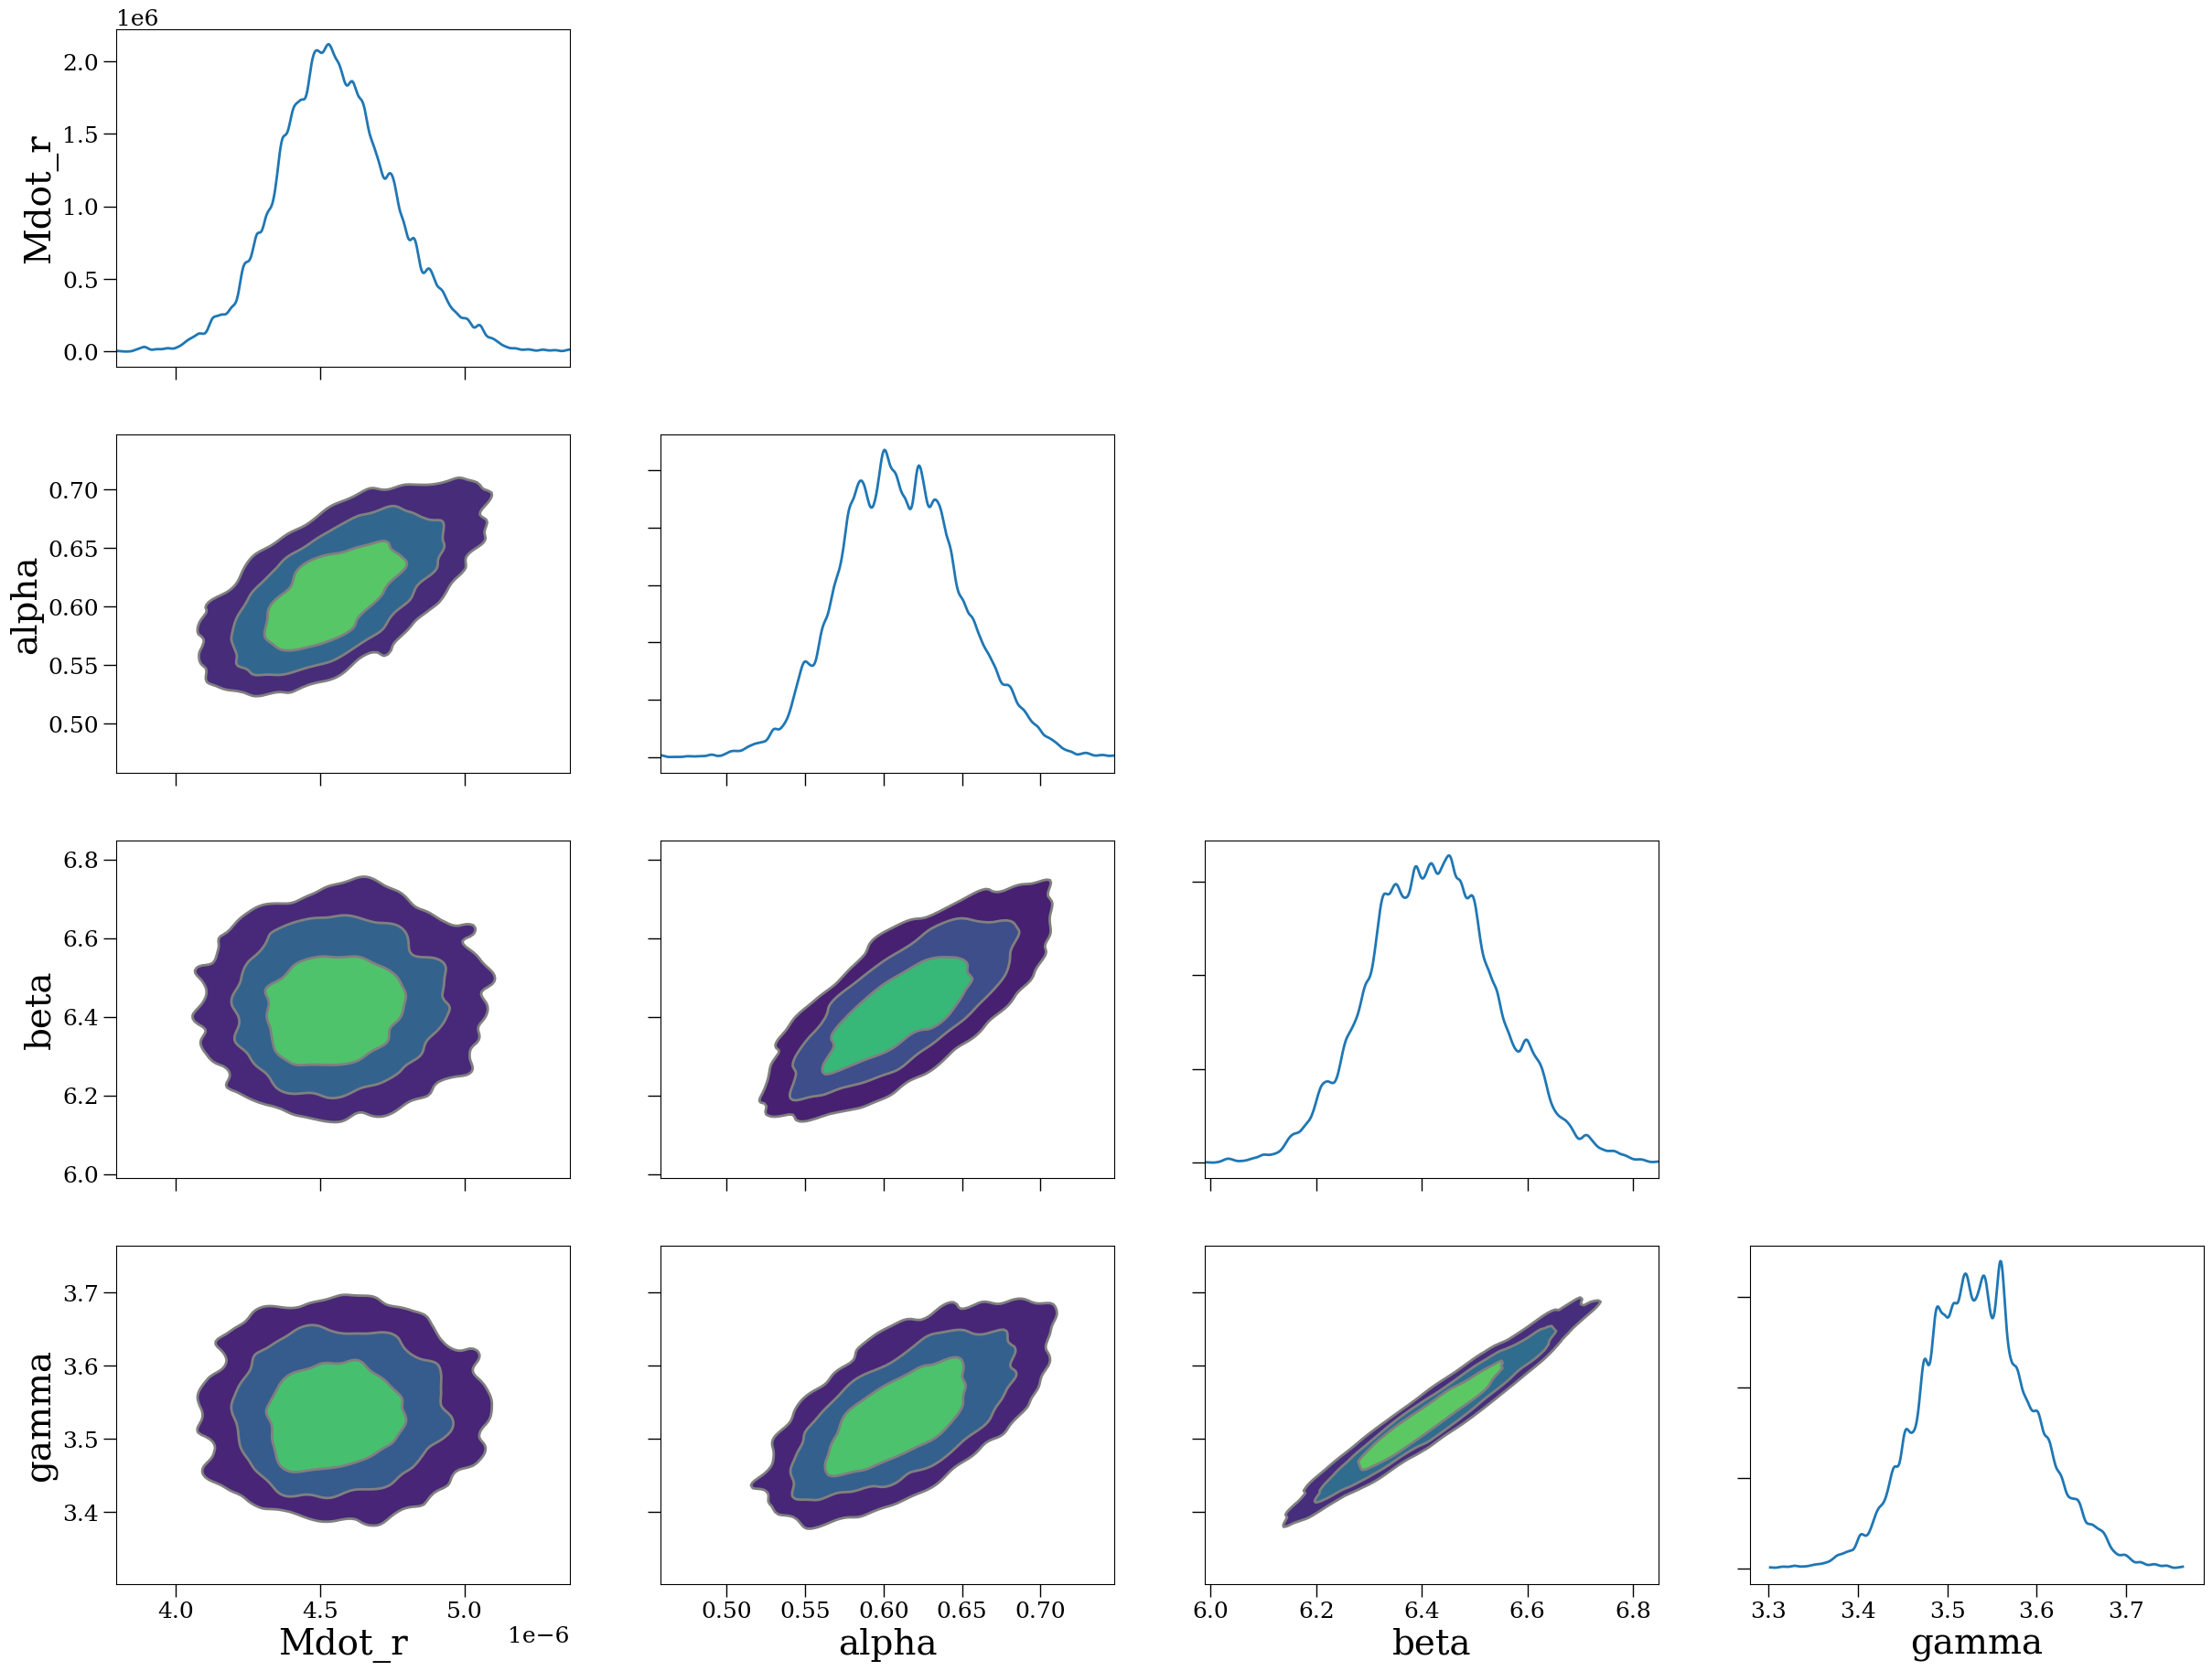

In [ ]:
data = core_props_df_old

draw_pop_old_kwargs = dict(
  model='surrogate',
  che_mask=True,
  metallicity='realistic',
  redshift=10.,
  res=int(1e8),
  min_m=10,
  max_m=300,
  min_p=0.1,
  max_p=4,
  min_zdivzsun=0.0005,
  max_zdivzsun=1.0,
  vars=[
    'm_f',
    #  'p_orb_f',
    #  'x_f',
    #  'min_x_f',
    'log_t_d'
    ],
  write_to_disk=False,
  verbose=True
  )

model = FinalVarModel(data)
sample = model.draw_pop(**draw_pop_old_kwargs)
msample = sample[sample[:, -1] <= np.log10(t_h)].copy()

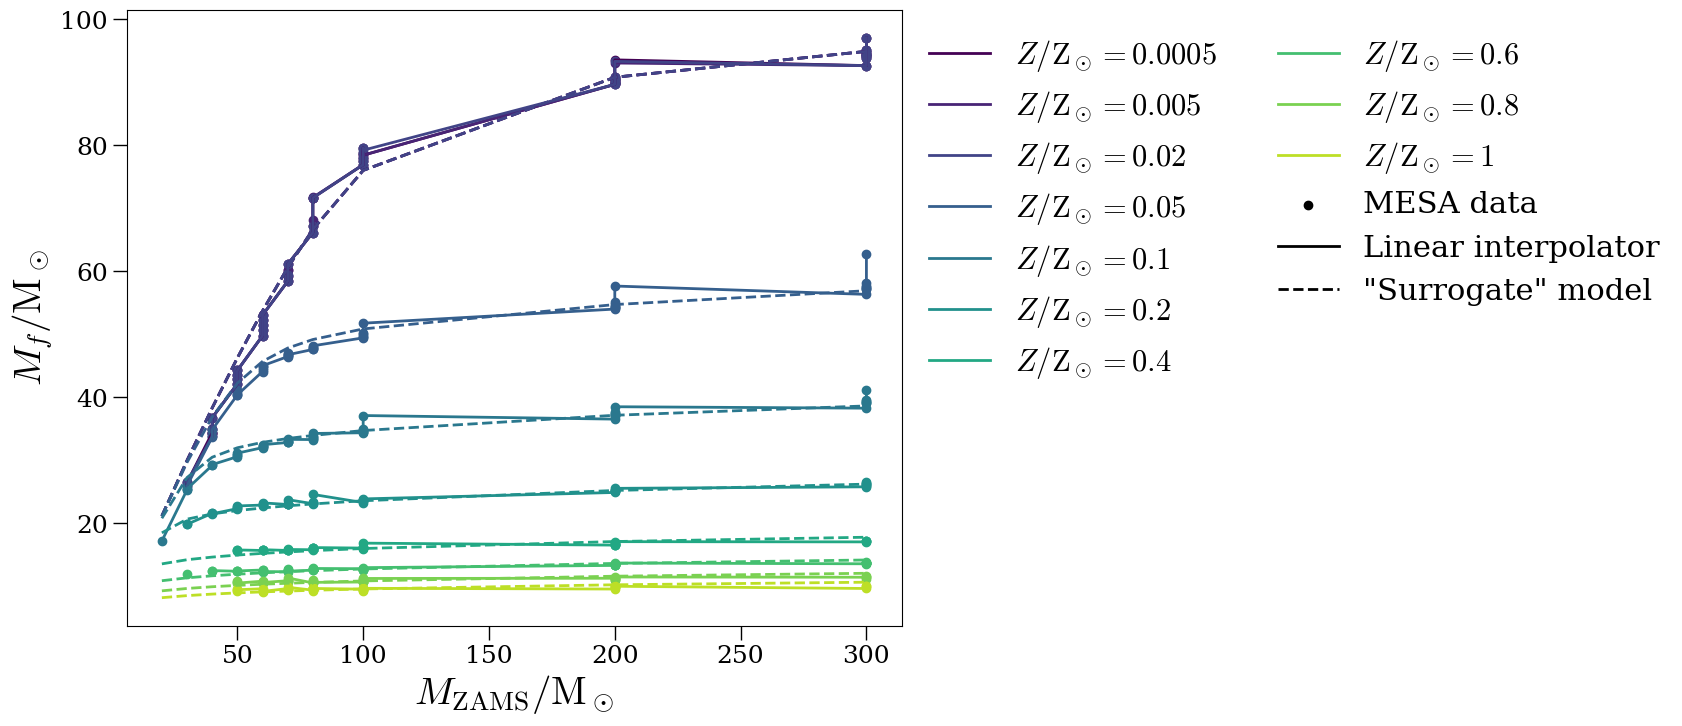

In [181]:
cmap = cm.viridis

fig, ax = plt.subplots(figsize=(10, 8))

for i, z in enumerate(data.z.unique()):
    subset = data[data.z == z]
    c = cmap(i / len(data.z.unique()))
    ax.scatter(subset.m_zams, subset.m_f, color=c)
    
    job = np.array([subset.z, subset.m_zams, subset.p_spin_zams]).T
    job = job[np.lexsort((job[:, 2], job[:, 1]))]  # Sort by p_spin_zams (column 2) and then by m_zams (column 1)
    
    ip_y = model.predict(job, var='m_f', model='interpolator', che_mask=False)
    ip_x = job[:, 1]  # Extract the sorted m_zams values
    ip_x = ip_x[~np.isnan(ip_y)]
    ip_y = ip_y[~np.isnan(ip_y)]
    ax.plot(ip_x, ip_y, color=c, ls='-', label=f'$Z/\\mathrm{{Z}}_\\odot={z:.2g}$')

    ip_y = model.predict(job, var='m_f', model='surrogate', che_mask=False)
    ip_x = job[:, 1]  # Extract the sorted m_zams values
    ip_x = ip_x[~np.isnan(ip_y)]
    ip_y = ip_y[~np.isnan(ip_y)]
    ax.plot(ip_x, ip_y, color=c, ls='--')
    
ax.set_xlabel(r'$M_{\mathrm{ZAMS}}/\mathrm{M}_\odot$')
ax.set_ylabel(r'$M_f/\mathrm{M}_\odot$')

handles, labels = ax.get_legend_handles_labels()
handles.append(
    ax.scatter([], [], color='black', label='MESA data')
)
handles.append(
    Line2D([0], [0], color='black', ls='-', label='Linear interpolator')
)
handles.append(
    Line2D([0], [0], color='black', ls='--', label='"Surrogate" model')
)
ax.legend(handles=handles, frameon=False, loc='upper left', bbox_to_anchor=(1, 1), ncol=2)

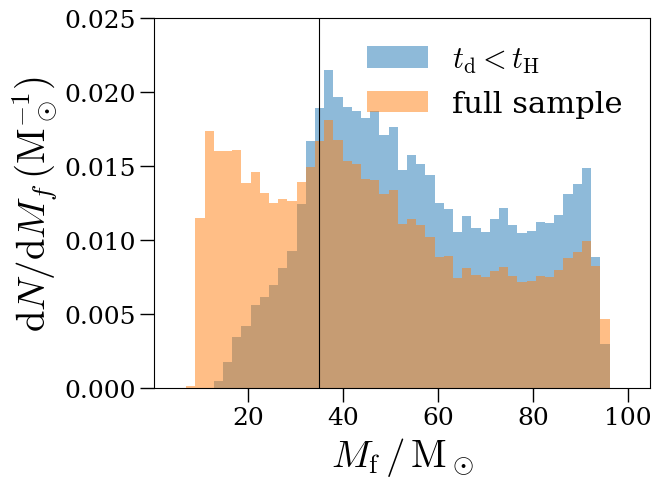

In [123]:
fig, ax = plt.subplots()

#bins = np.linspace(10, 100, 30) # for comparing with NB60
bins = np.linspace(5, 100, 50)

ax.hist(msample[:, 3], bins=bins, density=True, alpha=0.5, label='$t_\\mathrm{d}<t_\\mathrm{H}$')
ax.hist(sample[:, 3], bins=bins, density=True, alpha=0.5, label='full sample')
ax.vlines(35, 0, 1, color='k', lw=0.8)
ax.set_ylim(0, 0.025)
ax.set_xlabel('$M_\\mathrm{f} \\, / \\, \\mathrm{M}_\\odot$')
ax.set_ylabel('$\mathrm{d}N/\mathrm{d}M_f\,(\mathrm{M}_\\odot^{-1})$')
ax.legend(frameon=False)

(1.0, 110.0)

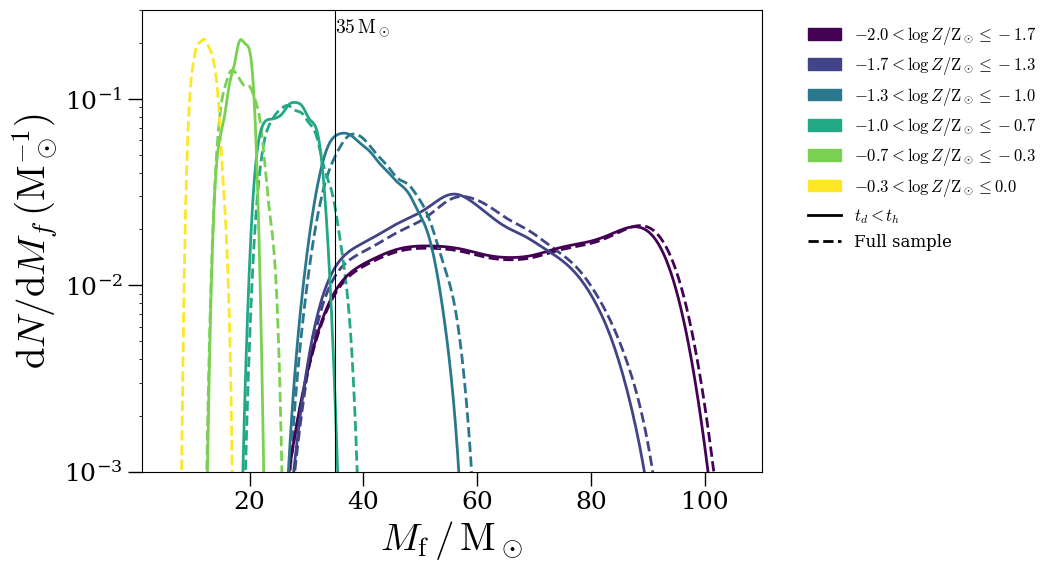

In [126]:
fig, ax = plt.subplots(figsize=(8, 6))

# Define 6 log-uniform intervals for metallicities
intervals = np.logspace(-2, 0, 7)  # 6 intervals, 7 boundaries
midpoints = np.sqrt(intervals[:-1] * intervals[1:])  # Midpoints for coloring

# Normalize the log of the midpoints for coloring
log_midpoints = np.log10(midpoints)
norm = plt.Normalize(log_midpoints.min(), log_midpoints.max())
cmap = plt.cm.viridis

# Plot KDE for the full sample
for i in range(len(intervals) - 1):
    mask = (sample[:, 0] >= intervals[i]) & (sample[:, 0] < intervals[i + 1])
    sns.kdeplot(
        sample[mask, 3],
        ax=ax,
        color=cmap(norm(np.log10(midpoints[i]))),
        linestyle='--'
    )

# Plot KDE for the t_d < t_h sample
for i in range(len(intervals) - 1):
    mask = (msample[:, 0] >= intervals[i]) & (msample[:, 0] < intervals[i + 1]) & ~np.isnan(msample[:, 3])
    sns.kdeplot(
        msample[mask, 3],
        ax=ax,
        color=cmap(norm(np.log10(midpoints[i]))),
        linestyle='-'
    )

ylim = (1e-3, 3e-1)
# Add a vertical line at 35
ax.vlines(35, 0, ylim[1], color='k', lw=0.8)
ax.text(35, ylim[1] * 0.8, '$35\,\mathrm{M}_\odot$', ha='left', va='center', fontsize=14)
ax.set_ylim(ylim)

# Set axis labels
ax.set_xlabel('$M_\\mathrm{f} \\, / \\, \\mathrm{M}_\\odot$')
ax.set_ylabel('$\mathrm{d}N/\mathrm{d}M_f\,(\mathrm{M}_\\odot^{-1})$')
ax.set_yscale('log')


# Create custom legend handles
metallicity_handles = [
    Patch(color=cmap(norm(np.log10(midpoints[i]))), label=f"${np.log10(intervals[i]):.1f}<\\log Z/\\mathrm{{Z}}_\\odot\leq {np.log10(intervals[i + 1]):.1f}$")
    for i in range(len(midpoints))
]
line_handles = [
    Line2D([0], [0], color='k', linestyle='-', label='$t_d < t_h$'),
    Line2D([0], [0], color='k', linestyle='--', label='Full sample')
]

# Combine handles and add legend
handles = metallicity_handles + line_handles
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
ax.set_xlim(1, 110)

/tmp/ipykernel_3215220/2716834260.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('viridis')


Text(0.5, 1, 'Metallicity distribution: realistic, redshift=10.0')

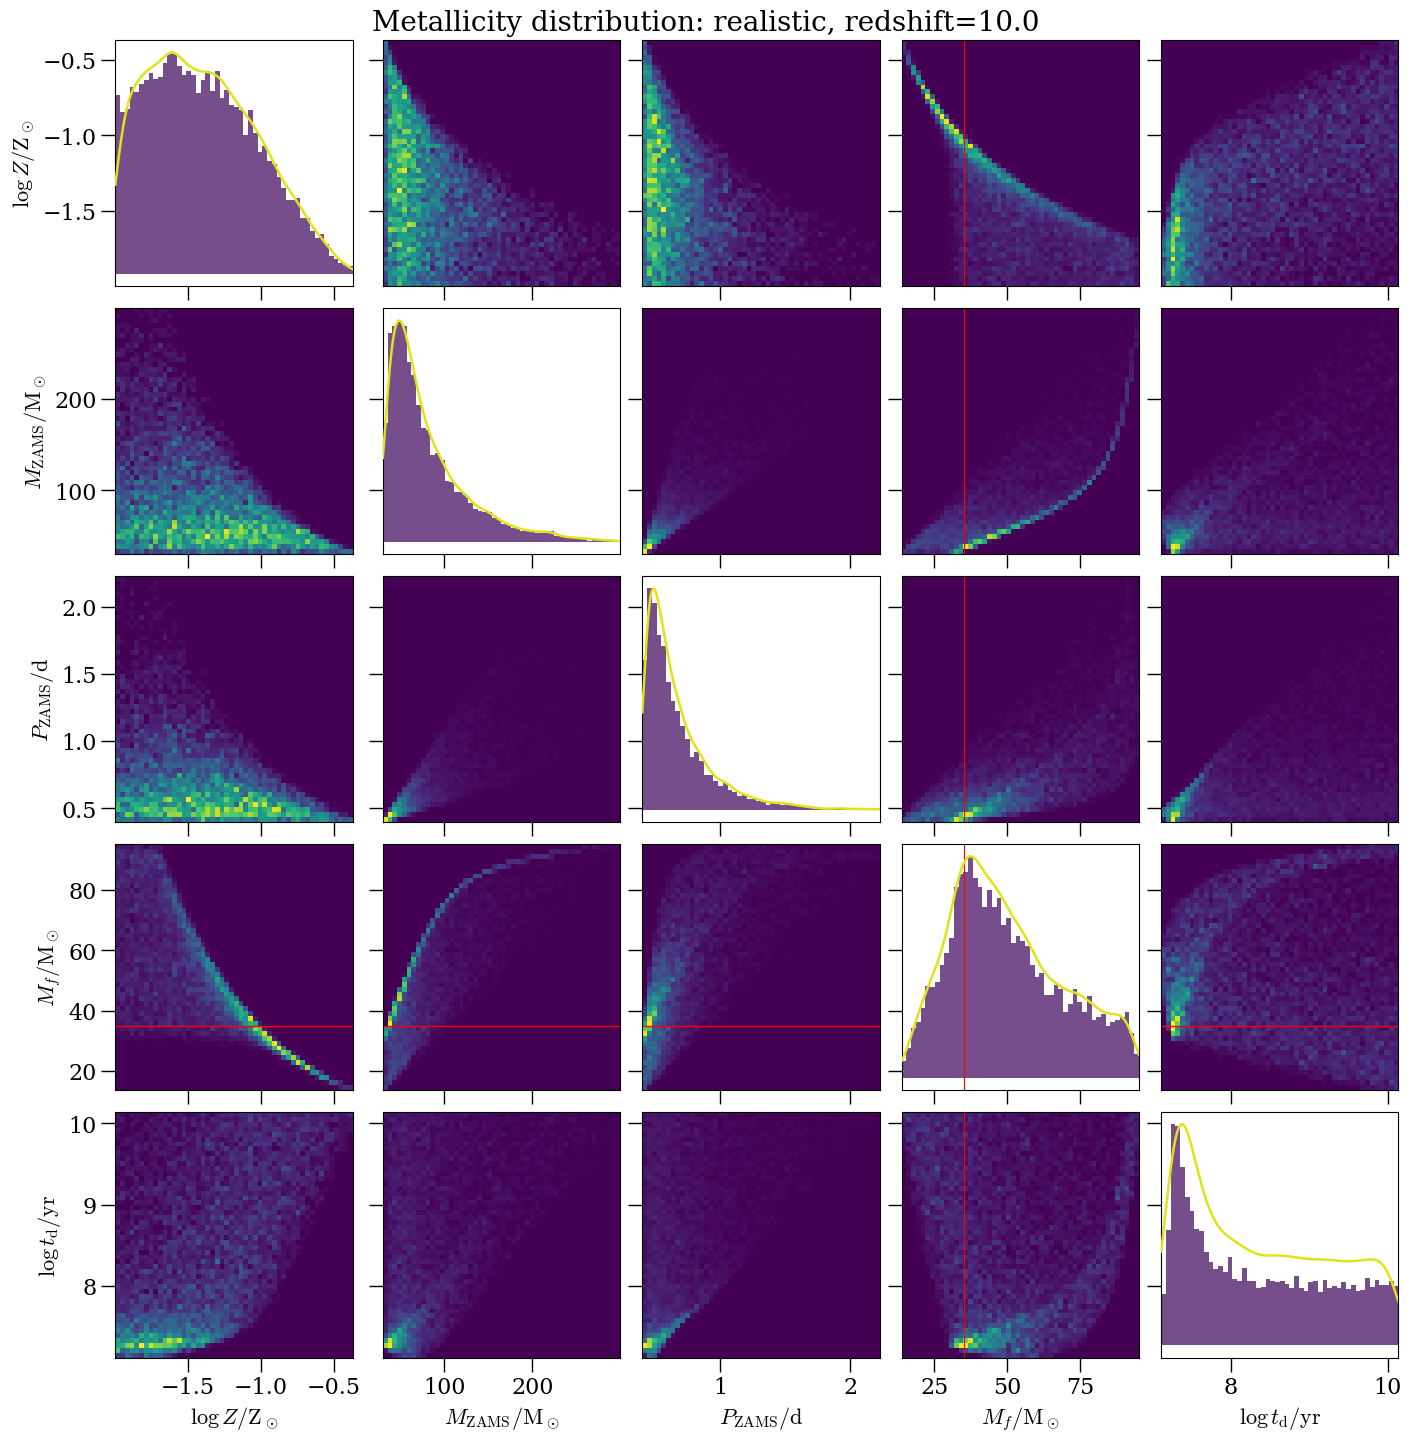

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # only for KDE on the diagonal
from matplotlib.cm import get_cmap

# ----------------------- Data prep -------------------------------------------
msample_df = pd.DataFrame(
    msample[msample[:,0] >= 0.01],
    columns=['$Z/\\mathrm{Z}_\\odot$', '$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$', '$P_\\mathrm{ZAMS}/\\mathrm{d}$', '$M_f/\\mathrm{M}_\\odot$', '$\\log t_\\mathrm{d}/\\mathrm{yr}$']
)
msample_df['$\\log Z/\\mathrm{Z}_\\odot$'] = np.log10(msample_df['$Z/\\mathrm{Z}_\\odot$'])
columns = ['$\\log Z/\\mathrm{Z}_\\odot$', '$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$', '$P_\\mathrm{ZAMS}/\\mathrm{d}$', '$M_f/\\mathrm{M}_\\odot$', '$\\log t_\\mathrm{d}/\\mathrm{yr}$']
msample_df = msample_df[columns]

# ----------------------- Figure / axes ---------------------------------------
n = len(columns)
figsize = (2.8*n, 2.8*n)
fig, axes = plt.subplots(
    n, n, figsize=figsize, constrained_layout=True,
    sharex='col', sharey='row'
)

# Colors from viridis extremes
cmap = get_cmap('viridis')
hist_color = cmap(0.05)
kde_color  = cmap(0.95)

# ----------------------- Bin edges (reused everywhere) -----------------------
bins_1d = 50
edges = {}
for col in columns:
    x = msample_df[col].to_numpy()
    edges[col] = np.histogram_bin_edges(x, bins=bins_1d)

# Diagonal normalization parameters
diag_height_frac = 0.9
center_diagonal = True
fontsize = 16

# ----------------------- Plot loop -------------------------------------------
for i in range(n):          # row -> y variable
    for j in range(n):      # col -> x variable
        ax = axes[i, j]
        xname, yname = columns[j], columns[i]
        x = msample_df[xname].to_numpy()
        y = msample_df[yname].to_numpy()
        xedges = edges[xname]
        yedges = edges[yname]

        if i == j:
            # ---- Diagonal: renormalize density into the row's y-range ----
            y0, y1 = yedges[0], yedges[-1]
            row_span = (y1 - y0)
            band_span = row_span * diag_height_frac
            if center_diagonal:
                y_base = y0 + 0.5 * (row_span - band_span)
            else:
                y_base = y0

            dens, _ = np.histogram(x, bins=xedges, density=True)
            if np.nanmax(dens) > 0:
                dens = dens / np.nanmax(dens)
            widths = np.diff(xedges)

            ax.bar(
                xedges[:-1], dens * band_span, width=widths, bottom=y_base,
                align='edge', color=hist_color, edgecolor='none', alpha=0.75, zorder=2
            )

            line = sns.kdeplot(
                x=x, ax=ax, lw=1.8, color=kde_color,
                clip=(xedges[0], xedges[-1]), zorder=3
            ).lines[-1]
            x_kde, y_kde = line.get_data()
            if np.nanmax(y_kde) > 0:
                y_kde = y_base + (y_kde / np.nanmax(y_kde)) * band_span
            else:
                y_kde = np.full_like(x_kde, y_base)
            line.set_data(x_kde, y_kde)

            ax.set_xlim(xedges[0], xedges[-1])
            ax.set_ylim(yedges[0], yedges[-1])

        else:
            # ---- Off-diagonal: 2D histogram with fixed edges ----
            H, _, _ = np.histogram2d(x, y, bins=[xedges, yedges], density=True)
            if np.nanmax(H) > 0:
                H = H / np.nanmax(H)

            X, Y = np.meshgrid(xedges, yedges)
            ax.pcolormesh(X, Y, H.T, cmap='viridis',
                          shading='auto', vmin=0.0, vmax=1.0)

            ax.set_xlim(xedges[0], xedges[-1])
            ax.set_ylim(yedges[0], yedges[-1])

        # Labels & ticks
        if j == 0:
            ax.set_ylabel(yname, fontsize=fontsize)
        else:
            ax.set_ylabel(None)

        if i == n - 1:
            ax.set_xlabel(xname, fontsize=fontsize)
        else:
            ax.set_xlabel(None)

        ax.tick_params(labelsize=fontsize)
        
        if xname == '$M_f/\\mathrm{M}_\\odot$':
            ylims = ax.get_ylim()
            ax.vlines(35, ylims[0], ylims[1], color='r', lw=0.8)
            ax.set_ylim(ylims)
        elif yname == '$M_f/\\mathrm{M}_\\odot$':
            xlims = ax.get_xlim()
            ax.hlines(35, xlims[0], xlims[1], color='r', lw=1.)
            ax.set_xlim(xlims)
fig.text(0.5, 1, f'Metallicity distribution: {draw_pop_old_kwargs["metallicity"]}, redshift={draw_pop_old_kwargs["redshift"]}', fontsize=20, ha='center', va='bottom', transform=fig.transFigure)


# Testing the linear interpolator vs analytical model

In [195]:
data[~np.isnan(data.m_f)].shape

(420, 65)

#### Scoring for generalization
Kfold split over $m_zams$ to evaluate the quality of extrapolating to masses outside the original dataset. Most relevant for extrapolating from low-res grids. 

In [203]:
import numpy as np
from sklearn.model_selection import train_test_split, KFold, GroupShuffleSplit, GroupKFold

# -----------------------
# 0) Filtering helpers
# -----------------------
def filter_valid_rows(df):
    """Keep only rows with valid target m_f."""
    return df[df['m_f'].notna()].reset_index(drop=True)

def filter_bins_with_min_count(df, min_per_bin=3):
    """
    Keep only rows for (z, m_zams) bins that have at least `min_per_bin` samples.
    Helps the interpolator avoid 'need at least 2 entries' after splitting.
    """
    keys = list(zip(df['z'].values, df['m_zams'].values))
    counts = {}
    for k in keys:
        counts[k] = counts.get(k, 0) + 1
    mask = np.array([counts[k] >= min_per_bin for k in keys], dtype=bool)
    kept = int(mask.sum()); dropped = int(len(mask) - kept)
    return df.loc[mask].reset_index(drop=True), kept, dropped

# -----------------------
# 1) Feature/target extraction
# -----------------------
def get_X_y(df):
    X = np.stack([df['z'], df['m_zams'], df['p_spin_zams']], axis=1)
    y = np.asarray(df['m_f'])
    return X, y

# -----------------------
# Helper: filter non-finite pairs
# -----------------------
def _finite_pairs(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return y_true[mask], y_pred[mask], int((~mask).sum())

# -----------------------
# 2) Metric (NaN/Inf-safe)
# -----------------------
def rmse(y_true, y_pred):
    y_true_f, y_pred_f, _ = _finite_pairs(y_true, y_pred)
    n = len(y_true_f)
    if n == 0:
        return np.nan
    return float(np.sqrt(np.mean((y_true_f - y_pred_f) ** 2)))

# -----------------------
# 2b) Fairness helpers (coverage, intersection RMSE, penalized RMSE)
# -----------------------
def _finite_mask(*arrs):
    arrs = [np.asarray(a).ravel() for a in arrs]
    masks = [np.isfinite(a) for a in arrs]
    return arrs, masks

def rmse_on_mask(y_true, y_pred, mask):
    y_t = np.asarray(y_true).ravel()[mask]
    y_p = np.asarray(y_pred).ravel()[mask]
    if y_t.size == 0:
        return np.nan
    return float(np.sqrt(np.mean((y_t - y_p) ** 2)))

def iqr_scale(y_true):
    y = np.asarray(y_true)
    y = y[np.isfinite(y)]
    if y.size < 2:
        return 1.0
    q1, q3 = np.percentile(y, [25, 75])
    if not (np.isfinite(q1) and np.isfinite(q3)):
        s = np.nanstd(y)
        return float(s if np.isfinite(s) and s > 0 else 1.0)
    iqr = q3 - q1
    return float(iqr if iqr > 0 else (np.nanstd(y) or 1.0))

def compare_models(y_true, y_lin, y_surr, penalty=None, penalty_multipliers=(0.5, 1.5, 3.0)):
    """
    Returns coverage + RMSE variants (drop-NaN, intersection) and penalized RMSEs
    for multiple penalty multipliers of IQR (or a fixed penalty if provided).
    """
    y_true = np.asarray(y_true).ravel()
    y_lin  = np.asarray(y_lin).ravel()
    y_surr = np.asarray(y_surr).ravel()

    m_true = np.isfinite(y_true)
    m_lin  = np.isfinite(y_lin)
    m_surr = np.isfinite(y_surr)

    m_both = m_true & m_lin & m_surr
    m_lin_only  = m_true & m_lin
    m_surr_only = m_true & m_surr

    n = int(m_true.sum())
    cov_lin  = float(m_lin_only.sum() / n) if n else 0.0
    cov_surr = float(m_surr_only.sum() / n) if n else 0.0

    # drop-NaN RMSEs (legacy)
    rmse_lin_drop  = rmse(y_true[m_lin_only],  y_lin[m_lin_only])
    rmse_surr_drop = rmse(y_true[m_surr_only], y_surr[m_surr_only])

    # intersection RMSEs
    rmse_lin_inter  = rmse(y_true[m_both], y_lin[m_both])
    rmse_surr_inter = rmse(y_true[m_both], y_surr[m_both])

    # baseline penalty scale
    base = penalty if (penalty is not None) else (1.0 * iqr_scale(y_true[m_true]))

    def penalized_rmse(y_t, y_p, pen):
        ok = np.isfinite(y_t) & np.isfinite(y_p)
        resid = np.empty_like(y_t, dtype=float)
        resid[ok]  = y_t[ok] - y_p[ok]
        resid[~ok] = pen
        return float(np.sqrt(np.mean(resid**2))) if resid.size else np.nan

    rmse_pen_multi_lin  = {}
    rmse_pen_multi_surr = {}
    for mult in penalty_multipliers:
        pen_val = base * float(mult)
        rmse_pen_multi_lin[mult]  = penalized_rmse(y_true, y_lin,  pen_val)
        rmse_pen_multi_surr[mult] = penalized_rmse(y_true, y_surr, pen_val)

    return {
        "coverage_lin": cov_lin,
        "coverage_surr": cov_surr,
        "rmse_lin_drop": rmse_lin_drop,
        "rmse_surr_drop": rmse_surr_drop,
        "rmse_intersection_lin": rmse_lin_inter,
        "rmse_intersection_surr": rmse_surr_inter,
        "rmse_penalized_multi": {  # dict: multiplier -> (lin, surr)
            mult: {"lin": rmse_pen_multi_lin[mult], "surr": rmse_pen_multi_surr[mult]}
            for mult in penalty_multipliers
        },
        "penalty_base_iqr": float(base),  # this is 1.0×IQR; actual used = base*mult
        "n_total": n,
        "n_both": int(m_both.sum())
    }

# -----------------------
# 2c) Safe prediction wrapper with progress prints
# -----------------------
def safe_predict(model, X, var, model_name):
    try:
        return model.predict(X, var=var, model=model_name)
    except Exception as e:
        print(f"[WARN] {model_name} prediction failed ({type(e).__name__}: {e}). "
              f"Filling {len(X)} predictions with NaN.")
        return np.full(len(X), np.nan, dtype=float)

# -----------------------
# 3) Holdout evaluation (group-wise by m_zams; train FinalVarModel on train split only)
# -----------------------
def evaluate_holdout(
    data,
    test_size=0.2,
    random_state=RANDOM_SEED,
    min_per_bin=3,
    echo_filter_summary=True
):
    print(f"[Holdout] Incoming rows: {len(data)}")
    valid = filter_valid_rows(data)
    print(f"[Holdout] Valid m_f rows: {len(valid)} (dropped {len(data)-len(valid)})")
    valid_bins, kept, dropped = filter_bins_with_min_count(valid, min_per_bin=min_per_bin)
    if echo_filter_summary:
        print(f"[Holdout] Bins filter (min_per_bin={min_per_bin}): kept {kept}, dropped {dropped}")

    if len(valid_bins) == 0:
        print("[Holdout] No data left after filtering; aborting.")
        return {
            "rmse_linear": np.nan, "rmse_surrogate": np.nan,
            "n_test_total": 0, "n_test_used_linear": 0, "n_test_used_surrogate": 0,
            "n_dropped_linear": 0, "n_dropped_surrogate": 0,
        }

    groups = valid_bins['m_zams'].values
    unique_groups = np.unique(groups)
    print(f"[Holdout] Unique m_zams groups: {len(unique_groups)}")

    print(f"[Holdout] Group-wise split by m_zams: test_size={test_size}, random_state={random_state}")
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    (train_idx, test_idx), = gss.split(np.arange(len(valid_bins)), groups=groups)

    data_tr = valid_bins.iloc[train_idx].reset_index(drop=True)
    data_te = valid_bins.iloc[test_idx].reset_index(drop=True)
    train_groups = np.unique(data_tr['m_zams'].values)
    test_groups  = np.unique(data_te['m_zams'].values)
    print(f"[Holdout] Train rows: {len(data_tr)} in {len(train_groups)} m_zams groups; "
          f"Test rows: {len(data_te)} in {len(test_groups)} groups.")

    Xte, yte = get_X_y(data_te)

    print("[Holdout] Fitting FinalVarModel on training split...")
    model = FinalVarModel(data_tr, verbose=False)

    print("[Holdout] Predicting (interpolator)...")
    yhat_lin = safe_predict(model, Xte, var='m_f', model_name='interpolator')

    print("[Holdout] Predicting (surrogate)...")
    yhat_surr = safe_predict(model, Xte, var='m_f', model_name='surrogate')

    # legacy metrics (drop-NaN) for backward compatibility
    yte_lin_f, yhat_lin_f, dropped_lin = _finite_pairs(yte, yhat_lin)
    yte_surr_f, yhat_surr_f, dropped_surr = _finite_pairs(yte, yhat_surr)

    # coverage-aware + penalized (multi)
    fair = compare_models(yte, yhat_lin, yhat_surr, penalty=None, penalty_multipliers=(0.5, 1.5, 3.0))

    print("[Holdout] Coverage lin={:.1%}, surr={:.1%}; intersection n={}/{}".format(
          fair["coverage_lin"], fair["coverage_surr"], fair["n_both"], fair["n_total"]))
    print("[Holdout] RMSE drop    lin={:.4g}, surr={:.4g}".format(fair["rmse_lin_drop"], fair["rmse_surr_drop"]))
    print("[Holdout] RMSE ∩(both) lin={:.4g}, surr={:.4g}".format(
          fair["rmse_intersection_lin"], fair["rmse_intersection_surr"]))
    # print multi-penalties
    for mult, vals in fair["rmse_penalized_multi"].items():
        print(f"[Holdout] RMSE penal (pen={mult:.1f}×IQR) lin={vals['lin']:.4g}, surr={vals['surr']:.4g}")

    out = {
        "rmse_linear": rmse(yte_lin_f, yhat_lin_f),
        "rmse_surrogate": rmse(yte_surr_f, yhat_surr_f),
        "n_test_total": int(len(yte)),
        "n_test_used_linear": int(len(yte_lin_f)),
        "n_test_used_surrogate": int(len(yte_surr_f)),
        "n_dropped_linear": dropped_lin,
        "n_dropped_surrogate": dropped_surr,
        "n_after_filters": int(len(valid_bins)),
        "n_groups_total": int(len(unique_groups)),
        "n_groups_train": int(len(train_groups)),
        "n_groups_test": int(len(test_groups)),
        "fair": fair,  # includes rmse_penalized_multi dict
    }
    print(f"[Holdout] Done. RMSE linear={out['rmse_linear']:.6g}, "
          f"surrogate={out['rmse_surrogate']:.6g}.")
    return out

# -----------------------
# 4) K-fold cross-validation (group-wise by m_zams; train FinalVarModel per-fold on train split only)
# -----------------------
def evaluate_kfold(
    data,
    n_splits=5,
    random_state=RANDOM_SEED,
    shuffle=True,
    min_per_bin=3,
    echo_filter_summary=True
):
    print(f"[CV] Incoming rows: {len(data)}")
    valid = filter_valid_rows(data)
    print(f"[CV] Valid m_f rows: {len(valid)} (dropped {len(data)-len(valid)})")
    valid_bins, kept, dropped = filter_bins_with_min_count(valid, min_per_bin=min_per_bin)
    if echo_filter_summary:
        print(f"[CV] Bins filter (min_per_bin={min_per_bin}): kept {kept}, dropped {dropped}")

    n = len(valid_bins)
    if n == 0:
        print("[CV] No data left after filtering; aborting.")
        return {
            "linear": {"mean": np.nan, "std": np.nan, "all_folds": []},
            "surrogate": {"mean": np.nan, "std": np.nan, "all_folds": []},
            "n_folds": 0,
            "n_used_linear_total": 0,
            "n_used_surrogate_total": 0,
            "n_dropped_linear_total": 0,
            "n_dropped_surrogate_total": 0,
            "n_after_filters": 0,
        }

    groups = valid_bins['m_zams'].values
    unique_groups = np.unique(groups)
    if n_splits > len(unique_groups):
        print(f"[CV] Reducing folds from {n_splits} to {len(unique_groups)} due to limited unique m_zams groups.")
        n_splits = len(unique_groups)
    if n_splits < 2:
        print("[CV] Need at least 2 folds; aborting.")
        return {
            "linear": {"mean": np.nan, "std": np.nan, "all_folds": []},
            "surrogate": {"mean": np.nan, "std": np.nan, "all_folds": []},
            "n_folds": 0,
            "n_used_linear_total": 0,
            "n_used_surrogate_total": 0,
            "n_dropped_linear_total": 0,
            "n_dropped_surrogate_total": 0,
            "n_after_filters": n,
        }

    print(f"[CV] Starting group-wise {n_splits}-fold CV by m_zams; rows after filters: {n}; "
          f"unique groups: {len(unique_groups)}")

    rng = np.random.default_rng(random_state)
    perm = rng.permutation(n)
    valid_bins = valid_bins.iloc[perm].reset_index(drop=True)
    groups = valid_bins['m_zams'].values

    gkf = GroupKFold(n_splits=n_splits)

    rmses_lin, rmses_surr = [], []
    dropped_lin_total = dropped_surr_total = 0
    used_lin_total = used_surr_total = 0

    # Fairness accumulators
    cov_lin_list, cov_surr_list = [], []
    rmse_drop_lin_list, rmse_drop_surr_list = [], []
    rmse_int_lin_list, rmse_int_surr_list = [], []
    # NEW: per-multiplier penalized trackers
    mults = (0.5, 1.5, 3.0)
    pen_lin_by_mult  = {m: [] for m in mults}
    pen_surr_by_mult = {m: [] for m in mults}

    for fold, (train_idx, test_idx) in enumerate(gkf.split(np.zeros(n), groups=groups, y=None), start=1):
        train_groups = np.unique(groups[train_idx])
        test_groups  = np.unique(groups[test_idx])
        print(f"[CV] Fold {fold}/{n_splits}: train={len(train_idx)} rows in {len(train_groups)} groups; "
              f"test={len(test_idx)} rows in {len(test_groups)} groups.")

        data_tr = valid_bins.iloc[train_idx].reset_index(drop=True)
        data_te = valid_bins.iloc[test_idx].reset_index(drop=True)

        Xte, yte = get_X_y(data_te)

        print(f"[CV] Fold {fold}: fitting FinalVarModel...")
        model = FinalVarModel(data_tr, verbose=False)

        print(f"[CV] Fold {fold}: predicting (interpolator)...")
        yhat_lin = safe_predict(model, Xte, var='m_f', model_name='interpolator')

        print(f"[CV] Fold {fold}: predicting (surrogate)...")
        yhat_surr = safe_predict(model, Xte, var='m_f', model_name='surrogate')

        yte_lin_f, yhat_lin_f, dropped_lin = _finite_pairs(yte, yhat_lin)
        yte_surr_f, yhat_surr_f, dropped_surr = _finite_pairs(yte, yhat_surr)

        r_lin = rmse(yte_lin_f, yhat_lin_f)
        r_surr = rmse(yte_surr_f, yhat_surr_f)
        rmses_lin.append(r_lin)
        rmses_surr.append(r_surr)

        dropped_lin_total += dropped_lin
        dropped_surr_total += dropped_surr
        used_lin_total += len(yte_lin_f)
        used_surr_total += len(yte_surr_f)

        fair = compare_models(yte, yhat_lin, yhat_surr, penalty=None, penalty_multipliers=mults)
        cov_lin_list.append(fair["coverage_lin"])
        cov_surr_list.append(fair["coverage_surr"])
        rmse_drop_lin_list.append(fair["rmse_lin_drop"])
        rmse_drop_surr_list.append(fair["rmse_surr_drop"])
        rmse_int_lin_list.append(fair["rmse_intersection_lin"])
        rmse_int_surr_list.append(fair["rmse_intersection_surr"])
        for m in mults:
            pen_lin_by_mult[m].append(fair["rmse_penalized_multi"][m]["lin"])
            pen_surr_by_mult[m].append(fair["rmse_penalized_multi"][m]["surr"])

        print(f"[CV] Fold {fold}: cov lin={fair['coverage_lin']:.1%}, surr={fair['coverage_surr']:.1%}; "
              f"RMSE∩ lin={fair['rmse_intersection_lin']:.4g}, surr={fair['rmse_intersection_surr']:.4g}")
        for m in mults:
            v = fair["rmse_penalized_multi"][m]
            print(f"[CV] Fold {fold}: RMSE penal (pen={m:.1f}×IQR) lin={v['lin']:.4g}, surr={v['surr']:.4g}")

    def summarize(arr):
        arr = np.array(arr, dtype=float)
        finite = np.isfinite(arr)
        return {
            "mean": float(np.nanmean(arr)) if finite.any() else np.nan,
            "std": float(np.nanstd(arr[finite], ddof=1)) if finite.sum() > 1 else np.nan,
            "all_folds": arr.tolist(),
        }

    fair_pen_summary = {
        m: {"lin": summarize(pen_lin_by_mult[m]), "surr": summarize(pen_surr_by_mult[m])}
        for m in mults
    }

    out = {
        "linear": summarize(rmses_lin),
        "surrogate": summarize(rmses_surr),
        "n_folds": int(n_splits),
        "n_used_linear_total": int(used_lin_total),
        "n_used_surrogate_total": int(used_surr_total),
        "n_dropped_linear_total": int(dropped_lin_total),
        "n_dropped_surrogate_total": int(dropped_surr_total),
        "n_after_filters": int(n),
        "n_groups_total": int(len(unique_groups)),
        "fair_summary": {
            "coverage_lin": summarize(cov_lin_list),
            "coverage_surr": summarize(cov_surr_list),
            "rmse_drop_lin": summarize(rmse_drop_lin_list),
            "rmse_drop_surr": summarize(rmse_drop_surr_list),
            "rmse_intersection_lin": summarize(rmse_int_lin_list),
            "rmse_intersection_surr": summarize(rmse_int_surr_list),
            # NEW: per-multiplier penalized summaries
            "rmse_penalized_multi": fair_pen_summary,
            "penalty_base_iqr_note": "penalty used per fold = (1.0×IQR_of_y_true_on_fold) × multiplier",
        }
    }

    print(f"[CV] Done. Linear mean RMSE={out['linear']['mean']:.6g} "
          f"(std={out['linear']['std']:.6g}); "
          f"Surrogate mean RMSE={out['surrogate']['mean']:.6g} "
          f"(std={out['surrogate']['std']:.6g}).")
    print("[CV] Fairness summary (means): "
          f"cov_lin={out['fair_summary']['coverage_lin']['mean']:.2%}, "
          f"cov_surr={out['fair_summary']['coverage_surr']['mean']:.2%}, "
          f"RMSE∩ lin={out['fair_summary']['rmse_intersection_lin']['mean']:.4g}, "
          f"surr={out['fair_summary']['rmse_intersection_surr']['mean']:.4g}")
    for m in mults:
        lin_m = out['fair_summary']['rmse_penalized_multi'][m]['lin']['mean']
        surr_m = out['fair_summary']['rmse_penalized_multi'][m]['surr']['mean']
        print(f"[CV] Penalized means (pen={m:.1f}×IQR): lin={lin_m:.4g}, surr={surr_m:.4g}")
    return out

# -----------------------
# 5) Bootstrap CI for RMSE on a single holdout
# -----------------------
def bootstrap_rmse_ci(y_true, y_pred, n_boot=1000, alpha=0.05, rng=RANDOM_SEED):
    y_true_f, y_pred_f, _ = _finite_pairs(y_true, y_pred)
    n = len(y_true_f)
    if n == 0:
        return (np.nan, np.nan)
    rng = np.random.default_rng(rng)
    stats = []
    for _ in range(int(n_boot)):
        idx = rng.integers(0, n, n)
        stats.append(rmse(y_true_f[idx], y_pred_f[idx]))
    stats = np.sort(np.array(stats, dtype=float))
    lo = stats[int((alpha/2)*n_boot)]
    hi = stats[int((1 - alpha/2)*n_boot)]
    return float(lo), float(hi)

# -----------------------
# 6) Example usage (group-wise splits; uses defaults for random_state)
# -----------------------
# Holdout (group-wise by m_zams)
print("\n=== GROUP SPLIT EVALUATION ===")
results_holdout = evaluate_holdout(data, test_size=0.2, min_per_bin=3)
print("Holdout RMSEs & counts:", results_holdout)

# CV (group-wise by m_zams)
results_cv = evaluate_kfold(data, n_splits=5, min_per_bin=3)
print("CV RMSE (linear):", results_cv["linear"])
print("CV RMSE (surrogate):", results_cv["surrogate"])
print("CV fairness summary:", results_cv["fair_summary"])
print("CV counts:", {k: v for k, v in results_cv.items() if k.endswith('_total') or k.startswith('n_')})



=== GROUP SPLIT EVALUATION ===
[Holdout] Incoming rows: 1600
[Holdout] Valid m_f rows: 420 (dropped 1180)
[Holdout] Bins filter (min_per_bin=3): kept 400, dropped 20
[Holdout] Unique m_zams groups: 8
[Holdout] Group-wise split by m_zams: test_size=0.2, random_state=42
[Holdout] Train rows: 299 in 6 m_zams groups; Test rows: 101 in 2 groups.
[Holdout] Fitting FinalVarModel on training split...


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]
Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 8 seconds.


[Holdout] Predicting (interpolator)...
[Holdout] Predicting (surrogate)...
[Holdout] Coverage lin=3.0%, surr=23.8%; intersection n=3/101
[Holdout] RMSE drop    lin=0.05672, surr=2.088
[Holdout] RMSE ∩(both) lin=0.05672, surr=3.852
[Holdout] RMSE penal (pen=0.5×IQR) lin=15.48, surr=13.76
[Holdout] RMSE penal (pen=1.5×IQR) lin=46.45, surr=41.19
[Holdout] RMSE penal (pen=3.0×IQR) lin=92.9, surr=82.36
[Holdout] Done. RMSE linear=0.056722, surrogate=2.08775.
Holdout RMSEs & counts: {'rmse_linear': 0.056721984944226846, 'rmse_surrogate': 2.0877457742709065, 'n_test_total': 101, 'n_test_used_linear': 3, 'n_test_used_surrogate': 24, 'n_dropped_linear': 98, 'n_dropped_surrogate': 77, 'n_after_filters': 400, 'n_groups_total': 8, 'n_groups_train': 6, 'n_groups_test': 2, 'fair': {'coverage_lin': 0.0297029702970297, 'coverage_surr': 0.2376237623762376, 'rmse_lin_drop': 0.056721984944226846, 'rmse_surr_drop': 2.0877457742709065, 'rmse_intersection_lin': 0.056721984944226846, 'rmse_intersection_surr'

Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]
Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 9 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[CV] Fold 1: predicting (interpolator)...
[CV] Fold 1: predicting (surrogate)...
[CV] Fold 1: cov lin=31.4%, surr=57.1%; RMSE∩ lin=2.337, surr=0.6709
[CV] Fold 1: RMSE penal (pen=0.5×IQR) lin=31.6, surr=24.96
[CV] Fold 1: RMSE penal (pen=1.5×IQR) lin=94.72, surr=74.87
[CV] Fold 1: RMSE penal (pen=3.0×IQR) lin=189.4, surr=149.7
[CV] Fold 2/5: train=334 rows in 7 groups; test=66 rows in 1 groups.
[CV] Fold 2: fitting FinalVarModel...


...

[CV] Fold 3: predicting (interpolator)...
[CV] Fold 3: predicting (surrogate)...
[CV] Fold 3: cov lin=0.0%, surr=76.2%; RMSE∩ lin=nan, surr=nan
[CV] Fold 3: RMSE penal (pen=0.5×IQR) lin=36.17, surr=17.66
[CV] Fold 3: RMSE penal (pen=1.5×IQR) lin=108.5, surr=52.89
[CV] Fold 3: RMSE penal (pen=3.0×IQR) lin=217, surr=105.8
[CV] Fold 4/5: train=313 rows in 6 groups; test=87 rows in 2 groups.
[CV] Fold 4: fitting FinalVarModel...


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]
Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 9 seconds.


[CV] Fold 4: predicting (interpolator)...
[CV] Fold 4: predicting (surrogate)...
[CV] Fold 4: cov lin=12.6%, surr=23.0%; RMSE∩ lin=1.229, surr=2.273
[CV] Fold 4: RMSE penal (pen=0.5×IQR) lin=14.38, surr=13.53
[CV] Fold 4: RMSE penal (pen=1.5×IQR) lin=43.14, surr=40.51
[CV] Fold 4: RMSE penal (pen=3.0×IQR) lin=86.27, surr=81
[CV] Fold 5/5: train=303 rows in 6 groups; test=97 rows in 2 groups.
[CV] Fold 5: fitting FinalVarModel...


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]
Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 9 seconds.


[CV] Fold 5: predicting (interpolator)...
[CV] Fold 5: predicting (surrogate)...
[CV] Fold 5: cov lin=11.3%, surr=21.6%; RMSE∩ lin=0.3989, surr=2.638
[CV] Fold 5: RMSE penal (pen=0.5×IQR) lin=17.54, surr=16.53
[CV] Fold 5: RMSE penal (pen=1.5×IQR) lin=52.61, surr=49.47
[CV] Fold 5: RMSE penal (pen=3.0×IQR) lin=105.2, surr=98.92
[CV] Done. Linear mean RMSE=1.32153 (std=0.972326); Surrogate mean RMSE=1.69819 (std=0.769301).
[CV] Fairness summary (means): cov_lin=11.08%, cov_surr=41.36%, RMSE∩ lin=1.322, surr=1.861
[CV] Penalized means (pen=0.5×IQR): lin=26.36, surr=19.96
[CV] Penalized means (pen=1.5×IQR): lin=79.06, surr=59.81
[CV] Penalized means (pen=3.0×IQR): lin=158.1, surr=119.6
CV RMSE (linear): {'mean': 1.3215327704066842, 'std': 0.972326124051354, 'all_folds': [2.3369116644379315, nan, nan, 1.2287799061114077, 0.3989067406707131]}
CV RMSE (surrogate): {'mean': 1.6981883792843433, 'std': 0.7693010255243801, 'all_folds': [0.5988334263104788, 2.1127239244108997, 1.3351122704805323,

#### Scoring for fidelity
Random kfold over all parameters (m_zams, z and p_spin_zams) to evaluate the quality of interpolation within the original dataset, or interpolating to the same masses but different z and p_spin_zams. Most relevant for high-res grids.

In [202]:
from sklearn.model_selection import train_test_split, KFold

# -----------------------
# Random-split Holdout
# -----------------------
def evaluate_holdout_random(
    data,
    test_size=0.2,
    random_state=RANDOM_SEED,
    min_per_bin=3,
    echo_filter_summary=True
):
    print(f"[Holdout-Random] Incoming rows: {len(data)}")
    valid = filter_valid_rows(data)
    print(f"[Holdout-Random] Valid m_f rows: {len(valid)} (dropped {len(data)-len(valid)})")
    valid_bins, kept, dropped = filter_bins_with_min_count(valid, min_per_bin=min_per_bin)
    if echo_filter_summary:
        print(f"[Holdout-Random] Bins filter (min_per_bin={min_per_bin}): kept {kept}, dropped {dropped}")

    if len(valid_bins) == 0:
        print("[Holdout-Random] No data left after filtering; aborting.")
        return {}

    idx = np.arange(len(valid_bins))
    train_idx, test_idx = train_test_split(idx, test_size=test_size, random_state=random_state)

    data_tr = valid_bins.iloc[train_idx].reset_index(drop=True)
    data_te = valid_bins.iloc[test_idx].reset_index(drop=True)

    print(f"[Holdout-Random] Train rows: {len(data_tr)}, Test rows: {len(data_te)}")

    Xte, yte = get_X_y(data_te)

    print("[Holdout-Random] Fitting FinalVarModel...")
    model = FinalVarModel(data_tr, verbose=False)

    yhat_lin  = safe_predict(model, Xte, var='m_f', model_name='interpolator')
    yhat_surr = safe_predict(model, Xte, var='m_f', model_name='surrogate')

    fair = compare_models(yte, yhat_lin, yhat_surr)
    print("[Holdout-Random] Coverage lin={:.1%}, surr={:.1%}".format(fair["coverage_lin"], fair["coverage_surr"]))
    print("[Holdout-Random] RMSE drop lin={:.4g}, surr={:.4g}".format(fair["rmse_lin_drop"], fair["rmse_surr_drop"]))
    print("[Holdout-Random] RMSE ∩ lin={:.4g}, surr={:.4g}".format(fair["rmse_intersection_lin"], fair["rmse_intersection_surr"]))
    print("[Holdout-Random] RMSE penal lin={:.4g}, surr={:.4g}".format(fair["rmse_penalized_lin"], fair["rmse_penalized_surr"]))

    return {"fair": fair}

# -----------------------
# Random-split K-fold CV
# -----------------------
def evaluate_kfold_random(
    data,
    n_splits=5,
    random_state=RANDOM_SEED,
    min_per_bin=3,
    echo_filter_summary=True
):
    print(f"[CV-Random] Incoming rows: {len(data)}")
    valid = filter_valid_rows(data)
    print(f"[CV-Random] Valid m_f rows: {len(valid)} (dropped {len(data)-len(valid)})")
    valid_bins, kept, dropped = filter_bins_with_min_count(valid, min_per_bin=min_per_bin)
    if echo_filter_summary:
        print(f"[CV-Random] Bins filter (min_per_bin={min_per_bin}): kept {kept}, dropped {dropped}")
    n = len(valid_bins)
    if n == 0:
        print("[CV-Random] No data left after filtering; aborting.")
        return {}

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rmses_lin, rmses_surr = [], []
    fair_list = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(valid_bins), start=1):
        data_tr = valid_bins.iloc[train_idx].reset_index(drop=True)
        data_te = valid_bins.iloc[test_idx].reset_index(drop=True)
        print(f"[CV-Random] Fold {fold}/{n_splits}: train={len(train_idx)}, test={len(test_idx)}")

        Xte, yte = get_X_y(data_te)

        model = FinalVarModel(data_tr, verbose=False)
        yhat_lin  = safe_predict(model, Xte, var='m_f', model_name='interpolator')
        yhat_surr = safe_predict(model, Xte, var='m_f', model_name='surrogate')

        fair = compare_models(yte, yhat_lin, yhat_surr)
        fair_list.append(fair)

        print(f"[CV-Random] Fold {fold}: cov_lin={fair['coverage_lin']:.1%}, cov_surr={fair['coverage_surr']:.1%}, "
              f"RMSE∩ lin={fair['rmse_intersection_lin']:.4g}, surr={fair['rmse_intersection_surr']:.4g}")

        rmses_lin.append(fair["rmse_lin_drop"])
        rmses_surr.append(fair["rmse_surr_drop"])

    def summarize(vals):
        arr = np.array(vals, dtype=float)
        return {"mean": float(np.nanmean(arr)), "std": float(np.nanstd(arr, ddof=1)), "all_folds": arr.tolist()}

    return {
        "linear": summarize(rmses_lin),
        "surrogate": summarize(rmses_surr),
        "fair": {k: summarize([f[k] for f in fair_list]) for k in fair_list[0].keys()}
    }

# -----------------------
# Example usage
# -----------------------
print("\n=== RANDOM SPLIT EVALUATION ===")
results_holdout_rand = evaluate_holdout_random(data, test_size=0.2)
print("Random Holdout Fairness:", results_holdout_rand["fair"])

results_cv_rand = evaluate_kfold_random(data, n_splits=5)
print("Random CV RMSE (linear):", results_cv_rand["linear"])
print("Random CV RMSE (surrogate):", results_cv_rand["surrogate"])
print("Random CV Fairness:", results_cv_rand["fair"])



=== RANDOM SPLIT EVALUATION ===
[Holdout-Random] Incoming rows: 1600
[Holdout-Random] Valid m_f rows: 420 (dropped 1180)
[Holdout-Random] Bins filter (min_per_bin=3): kept 400, dropped 20
[Holdout-Random] Train rows: 320, Test rows: 80
[Holdout-Random] Fitting FinalVarModel...


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]
Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 9 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


[Holdout-Random] Coverage lin=31.2%, surr=47.5%
[Holdout-Random] RMSE drop lin=0.1667, surr=1.498
[Holdout-Random] RMSE ∩ lin=0.1667, surr=1.021
[Holdout-Random] RMSE penal lin=53.39, surr=46.66
Random Holdout Fairness: {'coverage_lin': 0.3125, 'coverage_surr': 0.475, 'rmse_lin_drop': 0.16668224727026454, 'rmse_surr_drop': 1.4979581493359837, 'rmse_intersection_lin': 0.16668224727026454, 'rmse_intersection_surr': 1.0213871389625273, 'rmse_penalized_lin': 53.38561973089454, 'rmse_penalized_surr': 46.663063303478076, 'penalty_used': 64.3853818742119, 'n_total': 80, 'n_both': 25}
[CV-Random] Incoming rows: 1600
[CV-Random] Valid m_f rows: 420 (dropped 1180)
[CV-Random] Bins filter (min_per_bin=3): kept 400, dropped 20
[CV-Random] Fold 1/5: train=320, test=80


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]
Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 8 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


[CV-Random] Fold 1: cov_lin=31.2%, cov_surr=47.5%, RMSE∩ lin=0.1667, surr=1.021
[CV-Random] Fold 2/5: train=320, test=80


...

[CV-Random] Fold 3: cov_lin=26.2%, cov_surr=43.8%, RMSE∩ lin=0.2825, surr=1.016
[CV-Random] Fold 4/5: train=320, test=80


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]
Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 9 seconds.


[CV-Random] Fold 4: cov_lin=17.5%, cov_surr=38.8%, RMSE∩ lin=0.1103, surr=0.7534
[CV-Random] Fold 5/5: train=320, test=80


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]
Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 9 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[CV-Random] Fold 5: cov_lin=20.0%, cov_surr=40.0%, RMSE∩ lin=0.01763, surr=0.6656
Random CV RMSE (linear): {'mean': 0.18636365554035675, 'std': 0.13438162691128178, 'all_folds': [0.16668224727026454, 0.35475547443366473, 0.28245321652337213, 0.11029836151611562, 0.017628977958366685]}
Random CV RMSE (surrogate): {'mean': 1.378843238878607, 'std': 0.22016233421136347, 'all_folds': [1.4979581493359837, 1.2593968103697648, 1.121820899241695, 1.6895284303632876, 1.3255119050823034]}
Random CV Fairness: {'coverage_lin': {'mean': 0.225, 'std': 0.06059599821770412, 'all_folds': [0.3125, 0.175, 0.2625, 0.175, 0.2]}, 'coverage_surr': {'mean': 0.4025, 'std': 0.06085330722319042, 'all_folds': [0.475, 0.3125, 0.4375, 0.3875, 0.4]}, 'rmse_lin_drop': {'mean': 0.18636365554035675, 'std': 0.13438162691128178, 'all_folds': [0.16668224727026454, 0.35475547443366473, 0.28245321652337213, 0.11029836151611562, 0.017628977958366685]}, 'rmse_surr_drop': {'mean': 1.378843238878607, 'std': 0.22016233421136347,

# Producing synthetic samples

In [17]:
physics_model_titles

['00_fiducial',
 '01_small_fiducial',
 '02_weak_winds',
 '03_strong_winds',
 '04_flat_m_winds',
 '05_steep_m_winds',
 '06_flat_z_winds',
 '07_steep_z_winds',
 '08_late_wind_transition',
 '09_early_wind_transition',
 '10_inefficient_mix',
 '11_efficient_mix']

In [18]:
draw_pop_old_kwargs = dict(
    model='surrogate',
    che_mask=True,
    metallicity='loguniform',
    res=int(1e8),
    min_m=10,
    max_m=300,
    min_p=0.1,
    max_p=4,
    min_zdivzsun=0.0005,
    max_zdivzsun=1.0,
    vars=['m_f', 'log_t_d'],
    write_to_disk=True
)

def report_surrogate_fit(idata):
    """Print posterior summaries for key surrogate parameters."""
    post = idata.posterior
    def summarize(varname):
        arr = post[varname].stack(sample=("chain","draw")).values
        mean = float(np.mean(arr))
        med  = float(np.median(arr))
        q16, q84 = np.percentile(arr, [16, 84])
        return f"{varname}: mean={mean:.3f}, median={med:.3f}, 68% CI=({q16:.3f},{q84:.3f})"

    print("Surrogate fit summary:")
    for v in ["Mdot_r", "alpha", "beta", "gamma", "sigma"]:
        if v in post:
            print("  " + summarize(v))
    print()

for modelname, data in core_props_df_dict.items():
    print(f"\n=== DATASET: {modelname} ===")
    model = FinalVarModel(data, verbose=False, title=modelname)
    # report surrogate parameter posteriors
    if hasattr(model, "idata") and model.idata is not None:
        report_surrogate_fit(model.idata)

    sample = model.draw_pop(**draw_pop_old_kwargs)
    msample = sample[sample[:, -1] <= np.log10(t_h)].copy()
    print(f"Sampled {len(sample):,} systems, {len(msample):,} with t_d < t_H.")


=== DATASET: 01_small_fiducial ===


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]
Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 7 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Surrogate fit summary:
  Mdot_r: mean=0.000, median=0.000, 68% CI=(0.000,0.000)
  alpha: mean=0.174, median=0.178, 68% CI=(-0.010,0.361)
  beta: mean=4.843, median=4.855, 68% CI=(4.371,5.322)
  gamma: mean=2.732, median=2.738, 68% CI=(2.487,2.978)
  sigma: mean=2.703, median=2.597, 68% CI=(2.115,3.285)

Model: surrogate, che_mask: True


Model: surrogate, che_mask: True


Saved sample with 1000000 stars to /mnt/home/ldesa/repos/cher/data/01_small_fiducial_ip_pop_minz0.0005_maxz1.0_res1e+08_enhanced_w.npy
Saved sample with 16548 stars to /mnt/home/ldesa/repos/cher/data/01_small_fiducial_ip_pop_minz0.0005_maxz1.0_res1e+08_enhanced_w_mergers_only.npy
Sampled 1,000,000 systems, 16,548 with t_d < t_H.

=== DATASET: 03_strong_winds ===


...

Saved sample with 1000000 stars to /mnt/home/ldesa/repos/cher/data/10_inefficient_mix_ip_pop_minz0.0005_maxz1.0_res1e+08_enhanced_w.npy
Saved sample with 16737 stars to /mnt/home/ldesa/repos/cher/data/10_inefficient_mix_ip_pop_minz0.0005_maxz1.0_res1e+08_enhanced_w_mergers_only.npy
Sampled 1,000,000 systems, 16,737 with t_d < t_H.

=== DATASET: 11_efficient_mix ===


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]
Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 7 seconds.


Surrogate fit summary:
  Mdot_r: mean=0.000, median=0.000, 68% CI=(0.000,0.000)
  alpha: mean=0.266, median=0.266, 68% CI=(0.096,0.438)
  beta: mean=5.472, median=5.473, 68% CI=(4.944,6.015)
  gamma: mean=3.078, median=3.073, 68% CI=(2.797,3.366)
  sigma: mean=2.492, median=2.411, 68% CI=(1.923,3.053)

Model: surrogate, che_mask: True


Model: surrogate, che_mask: True


Saved sample with 1000000 stars to /mnt/home/ldesa/repos/cher/data/11_efficient_mix_ip_pop_minz0.0005_maxz1.0_res1e+08_enhanced_w.npy
Saved sample with 16836 stars to /mnt/home/ldesa/repos/cher/data/11_efficient_mix_ip_pop_minz0.0005_maxz1.0_res1e+08_enhanced_w_mergers_only.npy
Sampled 1,000,000 systems, 16,836 with t_d < t_H.


In [19]:
che_m_min = 40
draw_pop_old_kwargs = dict(
    model='surrogate',
    che_mask=True,
    metallicity='loguniform',
    res=int(1e8),
    min_m=10,
    max_m=300,
    min_p=0.1,
    max_p=4,
    min_zdivzsun=0.0005,
    max_zdivzsun=1.0,
    vars=['m_f', 'log_t_d'],
    write_to_disk=True
)

def report_surrogate_fit(idata):
    """Print posterior summaries for key surrogate parameters."""
    post = idata.posterior
    def summarize(varname):
        arr = post[varname].stack(sample=("chain","draw")).values
        mean = float(np.mean(arr))
        med  = float(np.median(arr))
        q16, q84 = np.percentile(arr, [16, 84])
        return f"{varname}: mean={mean:.3f}, median={med:.3f}, 68% CI=({q16:.3f},{q84:.3f})"

    print("Surrogate fit summary:")
    for v in ["Mdot_r", "alpha", "beta", "gamma", "sigma"]:
        if v in post:
            print("  " + summarize(v))
    print()

for modelname, data in core_props_df_dict.items():
    if modelname != '10_inefficient_mix':
        continue
    print(f"\n=== DATASET: {modelname} ===")
    model = FinalVarModel(data, verbose=False, title=modelname)
    # report surrogate parameter posteriors
    if hasattr(model, "idata") and model.idata is not None:
        report_surrogate_fit(model.idata)

    sample = model.draw_pop(**draw_pop_old_kwargs)
    msample = sample[sample[:, -1] <= np.log10(t_h)].copy()
    print(f"Sampled {len(sample):,} systems, {len(msample):,} with t_d < t_H.")


=== DATASET: 10_inefficient_mix ===


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [alpha, beta, log_Mdot_r, gamma, sigma]
Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 7 seconds.


Surrogate fit summary:
  Mdot_r: mean=0.000, median=0.000, 68% CI=(0.000,0.000)
  alpha: mean=0.130, median=0.138, 68% CI=(-0.049,0.309)
  beta: mean=4.954, median=4.975, 68% CI=(4.451,5.451)
  gamma: mean=2.822, median=2.832, 68% CI=(2.556,3.089)
  sigma: mean=2.415, median=2.281, 68% CI=(1.731,3.087)

Model: surrogate, che_mask: True


Model: surrogate, che_mask: True


Saved sample with 1000000 stars to /mnt/home/ldesa/repos/cher/data/10_inefficient_mix_ip_pop_minz0.0005_maxz1.0_res1e+08_enhanced_w.npy
Saved sample with 16855 stars to /mnt/home/ldesa/repos/cher/data/10_inefficient_mix_ip_pop_minz0.0005_maxz1.0_res1e+08_enhanced_w_mergers_only.npy
Sampled 1,000,000 systems, 16,855 with t_d < t_H.
